# Sydney Housing Price Prediction and Decision Support System

## SIT720 – Machine Learning Assessment 8.1 Distinction Task

### ML Mini Project

**Author:** Nixis Carrero  
**Date:** 09 September 2026

---

## Acknowledgement of AI Use

This assessment was completed with the assistance of **ChatGPT (OpenAI, September 2026)** as an academic learning tool.

ChatGPT was used to improve my understanding of machine learning concepts, Python programming, assist with debugging and fixing code, and review the clarity and structure of my written explanations. It also assisted in refining the presentation of figures, tables, and markdown documentation throughout the notebook.

All AI-generated suggestions were critically evaluated before being incorporated. The final code, data analysis, interpretations, and written content are my own work.

---

## Part 1. Problem Definition and Data Collection

### 1.1 Problem Definition

Residential property prices are influenced by a combination of property characteristics, location and surrounding amenities, making accurate valuation a complex prediction problem. The objective of this project is to develop a machine learning regression approach for predicting residential sale prices across three different Sydney suburbs.

The target variable is the **property sale price**, while potential predictors include property characteristics such as dwelling type, number of bedrooms and bathrooms, parking spaces and land size, together with location-related information. The project will investigate whether these characteristics can be used to explain differences in sale prices and generate useful predictions for previously unseen properties.

Rather than focusing only on predictive accuracy, the project will consider the complete machine learning workflow, including data collection, data quality, feature engineering, model development, evaluation, interpretation and practical deployment.

### 1.2 Selection of Sydney Suburbs

Three Sydney suburbs were selected to represent contrasting residential property markets: **Mosman, Parramatta and Liverpool**. The selection was designed to provide variation in property values, location, accessibility and dwelling characteristics rather than concentrating the analysis within a single type of housing market.

- **Mosman** represents a high-value residential market located close to Sydney Harbour and the CBD, with a combination of houses, apartments and townhouses.
- **Parramatta** represents a major metropolitan centre in Western Sydney, with a diverse residential market and strong access to employment, services and public transport.
- **Liverpool** represents a more affordable market further from the Sydney CBD, providing a useful contrast in location and property values.

Together, these suburbs provide variation in both **geographic location and housing prices**, allowing the project to investigate how property characteristics and location-related factors contribute to differences in sale price across different Sydney markets.

### 1.3 Data Collection Strategy

Property sales data were collected from **Domain.com.au** for Mosman, Parramatta and Liverpool. The search was restricted to residential properties with a confirmed sale date within the **2025–26 financial year (1 July 2025 to 30 June 2026)** and a publicly reported sale price. Properties with withheld or undisclosed prices were excluded because sale price is the target variable.

A structured sampling approach was used to obtain **120 properties**, with 40 properties from each suburb. To represent different dwelling types while maintaining a reasonably balanced dataset, the target sample within each suburb consisted of:

- 16 houses
- 16 apartments/units
- 8 townhouses

For each property, the dataset records the address, suburb, postcode, sale price, sale date, property type, bedrooms, bathrooms, parking spaces, land size, sale method and property description. The source and direct URL to the individual property listing were also retained to support traceability and verification.

Only information explicitly reported by the source was recorded. Values that were unavailable were retained as missing rather than estimated or inferred. Each property was included only once, and individual listing pages were used to verify the key property and sale information.

### 1.4 Dataset Description

The collected property sales dataset was loaded into Python for initial inspection. The dataset structure, number of observations, variables and data types were examined before performing any preprocessing or exploratory analysis.

In [1]:
# ============================================================
# 1.4 DATASET DESCRIPTION
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("Data/sydney_property_sales_mosman_parramatta_liverpool.csv")  # Load dataset

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 120 rows × 14 columns


,address,suburb,postcode,sale_price,sale_date,property_type,bedrooms,bathrooms,parking_spaces,land_size_m2,sale_method,property_description,source,listing_url
0,17 Avenue Road,Mosman,2088,5450000,2026-06-19,House,5,3,2.0,NaN,Private Treaty,"Circa-1903 Federation residence ""St Arnaud"" co...",Domain,https://www.domain.com.au/17-avenue-road-mosma...
1,5 Central Avenue,Mosman,2088,6399000,2026-06-19,House,5,4,2.0,607.0,Private Treaty,Newly renovated family residence with modern i...,Domain,https://www.domain.com.au/5-central-avenue-mos...
2,41 Lang Street,Mosman,2088,3350000,2026-05-01,House,3,2,NaN,329.0,Private Treaty,Federation-style residence with single-level l...,Domain,https://www.domain.com.au/41-lang-street-mosma...
3,6 Countess Street,Mosman,2088,3525000,2026-05-12,House,3,2,1.0,378.0,Private Treaty,Single-level freestanding home with high ceili...,Domain,https://www.domain.com.au/6-countess-street-mo...
4,3 Glover Street,Mosman,2088,5600000,2026-04-20,House,5,2,1.0,515.0,Private Treaty,Circa-1915 residence with thoughtful renovatio...,Domain,https://www.domain.com.au/3-glover-street-mosm...


In [2]:
# ============================================================
# DATASET STRUCTURE
# ============================================================

print("=== Dataset Structure ===")
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes)

=== Dataset Structure ===
Rows   : 120
Columns: 14

=== Data Types ===
address                     str
suburb                      str
postcode                  int64
sale_price                int64
sale_date                   str
property_type               str
bedrooms                  int64
bathrooms                 int64
parking_spaces          float64
land_size_m2            float64
sale_method                 str
property_description        str
source                      str
listing_url                 str
dtype: object


In [3]:
# ============================================================
# VARIABLE SUMMARY
# ============================================================

print("=== Variable Summary ===")
print(f"{'Variable':<24} {'Type':<12} {'Non-Missing':>12} {'Missing':>10}")
print("-" * 62)

for col in df.columns:
    print(f"{col:<24} {str(df[col].dtype):<12} "
          f"{df[col].notna().sum():>12} {df[col].isna().sum():>10}")    # Variable details

=== Variable Summary ===
Variable                 Type          Non-Missing    Missing
--------------------------------------------------------------
address                  str                   120          0
suburb                   str                   120          0
postcode                 int64                 120          0
sale_price               int64                 120          0
sale_date                str                   120          0
property_type            str                   120          0
bedrooms                 int64                 120          0
bathrooms                int64                 120          0
parking_spaces           float64               116          4
land_size_m2             float64                66         54
sale_method              str                   120          0
property_description     str                   120          0
source                   str                   120          0
listing_url              str                

### 1.5 Data Quality, Missing Information, Bias and Limitations

Before exploratory analysis and modelling, the dataset was assessed for completeness, duplicate records and consistency. Missing values were examined to determine where information was unavailable and whether the missingness was associated with particular property characteristics.

In [4]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================

print("=== Data Quality Report ===")
print(f"Observations        : {len(df)}")                               # Total properties
print(f"Variables           : {df.shape[1]}")                           # Total variables
print(f"Duplicate rows      : {df.duplicated().sum()}")                # Exact duplicates
print(f"Duplicate addresses : {df['address'].duplicated().sum()}")     # Repeated properties
print(f"Missing values      : {df.isna().sum().sum()}")                # Total missing cells
print(f"Missing sale prices : {df['sale_price'].isna().sum()}")        # Missing target

=== Data Quality Report ===
Observations        : 120
Variables           : 14
Duplicate rows      : 0
Duplicate addresses : 0
Missing values      : 58
Missing sale prices : 0


In [5]:
# ============================================================
# MISSING VALUES BY PROPERTY TYPE
# ============================================================

print("=== Missing Values by Property Type ===")

for ptype, group in df.groupby("property_type"):
    print(f"\n{ptype} (n={len(group)})")
    print(f"  Land size missing : {group['land_size_m2'].isna().sum()}")    # Missing land size
    print(f"  Parking missing   : {group['parking_spaces'].isna().sum()}") # Missing parking

=== Missing Values by Property Type ===

Apartment-Unit (n=48)
  Land size missing : 36
  Parking missing   : 3

House (n=48)
  Land size missing : 8
  Parking missing   : 1

Townhouse (n=24)
  Land size missing : 10
  Parking missing   : 0


In [6]:
# ============================================================
# SAMPLE BALANCE
# ============================================================

print("=== Properties by Suburb ===")
print(df["suburb"].value_counts().sort_index())                         # Suburb counts

print("\n=== Properties by Property Type ===")
print(df["property_type"].value_counts())                              # Dwelling counts

print("\n=== Suburb × Property Type ===")
print(pd.crosstab(df["suburb"], df["property_type"]))                  # Sampling structure

=== Properties by Suburb ===
suburb
Liverpool     40
Mosman        40
Parramatta    40
Name: count, dtype: int64

=== Properties by Property Type ===
property_type
House             48
Apartment-Unit    48
Townhouse         24
Name: count, dtype: int64

=== Suburb × Property Type ===
property_type  Apartment-Unit  House  Townhouse
suburb                                         
Liverpool                  16     16          8
Mosman                     16     16          8
Parramatta                 16     16          8


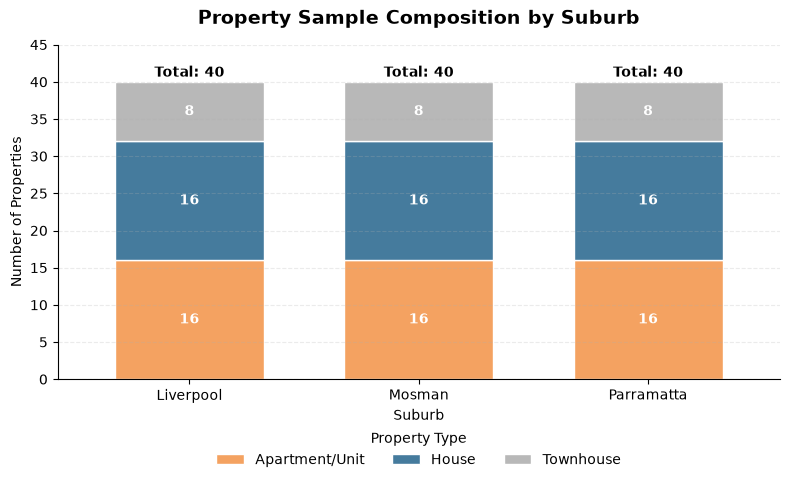

In [96]:
# ============================================================
# VISUALISATION OF THE CONTROLLED SAMPLING DESIGN
# ============================================================

sample_counts = pd.crosstab(                          # Create count table
    df["suburb"],
    df["property_type"]
)

sample_counts = sample_counts.loc[                    # Set category order
    ["Liverpool", "Mosman", "Parramatta"],
    ["Apartment-Unit", "House", "Townhouse"]
]

ax = sample_counts.plot(                              # Create stacked bars
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#F4A261", "#457B9D", "#B8B8B8"],
    edgecolor="white",
    width=0.65
)

for container in ax.containers:                       # Label each segment
    ax.bar_label(
        container,
        label_type="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

for i, total in enumerate(sample_counts.sum(axis=1)): # Add suburb totals
    ax.text(
        i,
        total + 0.7,
        f"Total: {total}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(                                         # Add chart title
    "Property Sample Composition by Suburb",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Suburb")                               # Label x-axis
ax.set_ylabel("Number of Properties")                 # Label y-axis
ax.set_ylim(0, 45)                                    # Set y-axis range
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Keep labels horizontal

ax.legend(                                            # Format legend
    title="Property Type",
    labels=["Apartment/Unit", "House", "Townhouse"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

ax.spines["top"].set_visible(False)                    # Remove top border
ax.spines["right"].set_visible(False)                  # Remove right border
ax.grid(axis="y", linestyle="--", alpha=0.25)          # Add light gridlines

plt.tight_layout()                                    # Optimise spacing
plt.show()                                            # Display chart

In [7]:
# ============================================================
# SALE DATE COVERAGE
# ============================================================

df["sale_date"] = pd.to_datetime(df["sale_date"])                       # Convert to datetime

print("=== Sale Date Coverage ===")
print(f"Earliest sale       : {df['sale_date'].min().date()}")          # First sale
print(f"Latest sale         : {df['sale_date'].max().date()}")           # Last sale
print(f"Invalid dates       : {df['sale_date'].isna().sum()}")           # Conversion failures
print(f"Outside study period: {((df['sale_date'] < '2025-07-01') | (df['sale_date'] > '2026-06-30')).sum()}")  # Range check

=== Sale Date Coverage ===
Earliest sale       : 2025-09-20
Latest sale         : 2026-06-30
Invalid dates       : 0
Outside study period: 0


**Observation.** The quality checks identified no duplicate properties, no missing sale prices and no records outside the defined study period. The intended sampling structure was also confirmed, with 40 properties from each suburb and the same 16 houses, 16 apartments/units and 8 townhouses in each location.

Missing information was limited to land size and parking. Land size showed substantial and uneven missingness, particularly for apartments (36 of 48), compared with houses (8 of 48) and townhouses (10 of 24). This suggests that land-size missingness is partly related to dwelling type rather than being completely random, and it will therefore require careful treatment during modelling rather than simple automatic imputation.

The dataset also has limitations. The quota-based sampling provides useful comparability between suburbs and dwelling types but does not necessarily represent their true proportions in the Sydney property market. Properties with undisclosed sale prices were excluded, and the analysis is limited to three suburbs and publicly available Domain listings. These factors may introduce selection bias and limit how well the resulting models generalise beyond the markets and period represented in the dataset.

## Part 2. Data Understanding and Feature Engineering

Exploratory data analysis was conducted to understand the distribution of residential sale prices and how prices vary across suburbs, dwelling types and time. Potential unusual observations were also investigated before model development. These initial patterns were used to establish expectations about the most influential predictors before additional features were engineered.

### 2.1 Housing Price Distribution

The overall distribution of sale prices was examined first to understand the range, central tendency and variability of the target variable and to identify possible skewness or extreme observations.


In [8]:
# ============================================================
# SALE PRICE SUMMARY
# ============================================================

print("=== Sale Price Summary ===")
print(f"Minimum : ${df['sale_price'].min():,.0f}")                      # Lowest sale
print(f"Q1      : ${df['sale_price'].quantile(0.25):,.0f}")             # 25th percentile
print(f"Median  : ${df['sale_price'].median():,.0f}")                   # Median sale
print(f"Mean    : ${df['sale_price'].mean():,.0f}")                     # Average sale
print(f"Q3      : ${df['sale_price'].quantile(0.75):,.0f}")             # 75th percentile
print(f"Maximum : ${df['sale_price'].max():,.0f}")                      # Highest sale
print(f"Std Dev : ${df['sale_price'].std():,.0f}")                      # Price variability

=== Sale Price Summary ===
Minimum : $390,000
Q1      : $742,500
Median  : $1,317,500
Mean    : $1,805,786
Q3      : $2,125,000
Maximum : $8,750,000
Std Dev : $1,554,743


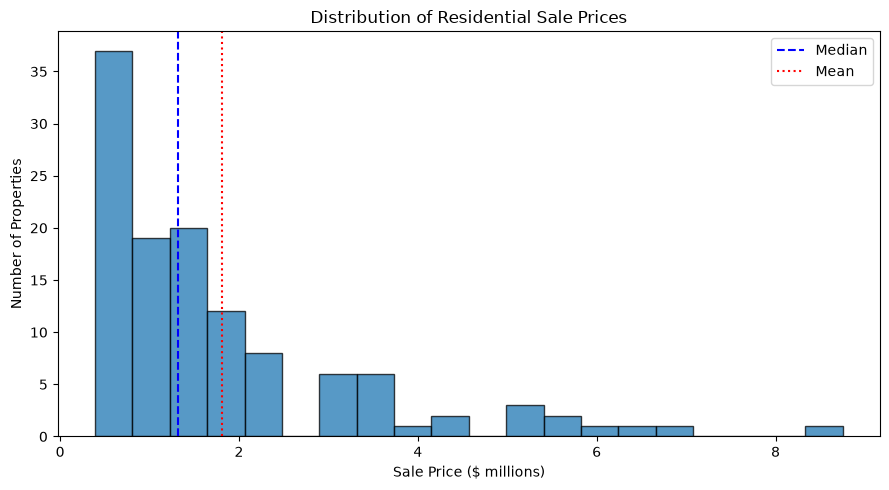

In [9]:
# ============================================================
# SALE PRICE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

prices_m = df["sale_price"] / 1_000_000                                # Convert to millions

plt.figure(figsize=(9, 5))
plt.hist(prices_m, bins=20, edgecolor="black", alpha=0.75)             # Price distribution
plt.axvline(prices_m.median(), color="blue", linestyle="--",
            label="Median")                                            # Median price
plt.axvline(prices_m.mean(), color="red", linestyle=":",
            label="Mean")                                              # Mean price

plt.xlabel("Sale Price ($ millions)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Residential Sale Prices")
plt.legend()
plt.tight_layout()
plt.show()

**Observation.** Sale prices show a strongly right-skewed distribution, with most properties concentrated below approximately AUD 2 million and a smaller number of high-value sales extending the upper tail to AUD 8.75 million. Consequently, the mean sale price (AUD 1.81 million) is substantially higher than the median (AUD 1.32 million). This wide price range suggests considerable variation within the dataset and indicates that the higher-priced properties should be examined further when investigating potential outliers.

### 2.2 Price Differences Between Suburbs

Sale prices were compared across Mosman, Parramatta and Liverpool to examine whether the contrasting housing markets identified during suburb selection are reflected in the collected data.

In [10]:
# ============================================================
# SALE PRICE BY SUBURB
# ============================================================

print("=== Sale Price by Suburb ===")

for suburb, group in df.groupby("suburb"):
    print(f"\n{suburb} (n={len(group)})")
    print(f"  Mean    : AUD {group['sale_price'].mean():,.0f}")             # Average price
    print(f"  Median  : AUD {group['sale_price'].median():,.0f}")           # Median price
    print(f"  Minimum : AUD {group['sale_price'].min():,.0f}")              # Lowest price
    print(f"  Maximum : AUD {group['sale_price'].max():,.0f}")              # Highest price

=== Sale Price by Suburb ===

Liverpool (n=40)
  Mean    : AUD 893,925
  Median  : AUD 795,000
  Minimum : AUD 390,000
  Maximum : AUD 1,732,000

Mosman (n=40)
  Mean    : AUD 3,396,738
  Median  : AUD 3,000,000
  Minimum : AUD 788,000
  Maximum : AUD 8,750,000

Parramatta (n=40)
  Mean    : AUD 1,126,695
  Median  : AUD 1,084,750
  Minimum : AUD 420,000
  Maximum : AUD 2,300,000


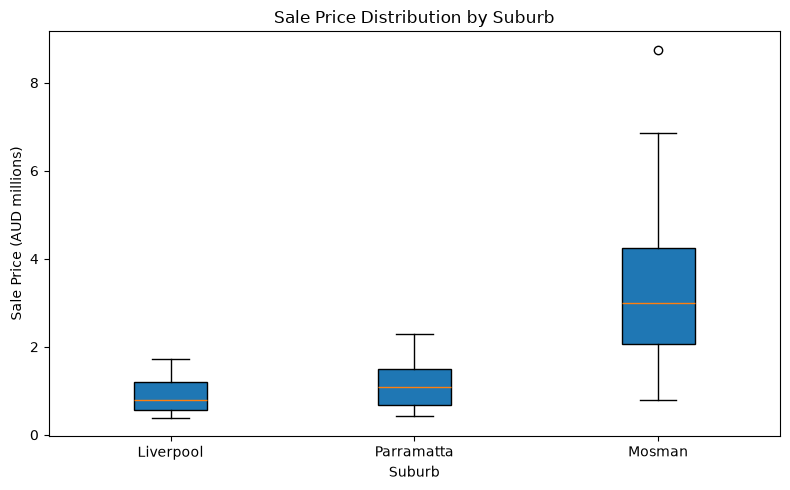

In [11]:
# ============================================================
# SALE PRICE DISTRIBUTION BY SUBURB
# ============================================================

suburbs = ["Liverpool", "Parramatta", "Mosman"]                         # Comparison order
price_data = [df.loc[df["suburb"] == s, "sale_price"] / 1_000_000
              for s in suburbs]                                        # Prices in millions

plt.figure(figsize=(8, 5))
plt.boxplot(price_data, tick_labels=suburbs, patch_artist=True)         # Compare distributions

plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD millions)")
plt.title("Sale Price Distribution by Suburb")
plt.tight_layout()
plt.show()

**Observation.** Sale prices differ substantially across the three suburbs. Liverpool has the lowest median price (AUD 795,000), followed by Parramatta (AUD 1.08 million), while Mosman has a considerably higher median of AUD 3.00 million. Mosman also shows the greatest price variability, with sales extending to AUD 8.75 million. These results support the initial selection of the three suburbs as contrasting property markets and indicate that suburb location is likely to be an important predictor of sale price.

### 2.3 Price Differences Between Property Types

Sale prices were also compared across houses, apartments/units and townhouses to investigate whether dwelling type contributes to the observed variation in property values.

In [12]:
# ============================================================
# SALE PRICE BY PROPERTY TYPE
# ============================================================

print("=== Sale Price by Property Type ===")

for ptype, group in df.groupby("property_type"):
    print(f"\n{ptype} (n={len(group)})")
    print(f"  Mean    : AUD {group['sale_price'].mean():,.0f}")             # Average price
    print(f"  Median  : AUD {group['sale_price'].median():,.0f}")           # Median price
    print(f"  Minimum : AUD {group['sale_price'].min():,.0f}")              # Lowest price
    print(f"  Maximum : AUD {group['sale_price'].max():,.0f}")              # Highest price

=== Sale Price by Property Type ===

Apartment-Unit (n=48)
  Mean    : AUD 1,223,019
  Median  : AUD 662,750
  Minimum : AUD 390,000
  Maximum : AUD 6,000,000

House (n=48)
  Mean    : AUD 2,565,498
  Median  : AUD 1,650,000
  Minimum : AUD 1,000,000
  Maximum : AUD 8,750,000

Townhouse (n=24)
  Mean    : AUD 1,451,896
  Median  : AUD 1,084,750
  Minimum : AUD 600,000
  Maximum : AUD 3,300,000


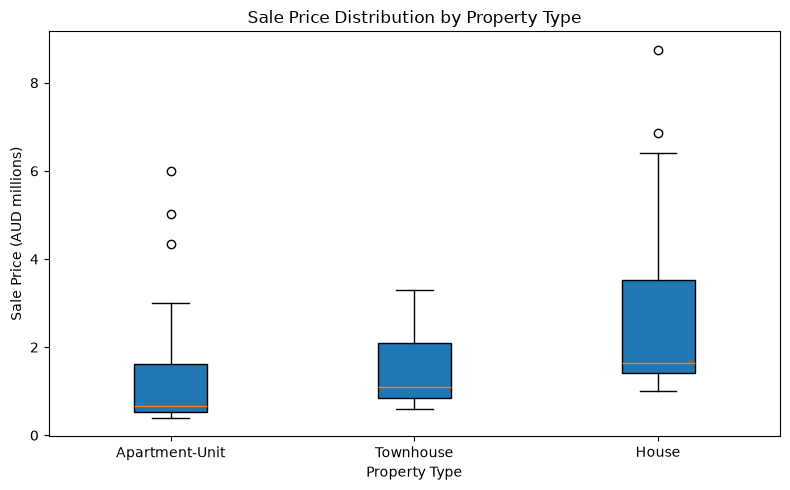

In [13]:
# ============================================================
# SALE PRICE DISTRIBUTION BY PROPERTY TYPE
# ============================================================

property_types = ["Apartment-Unit", "Townhouse", "House"]               # Comparison order
price_data = [df.loc[df["property_type"] == p, "sale_price"] / 1_000_000
              for p in property_types]                                  # Prices in millions

plt.figure(figsize=(8, 5))
plt.boxplot(price_data, tick_labels=property_types, patch_artist=True)   # Compare distributions

plt.xlabel("Property Type")
plt.ylabel("Sale Price (AUD millions)")
plt.title("Sale Price Distribution by Property Type")
plt.tight_layout()
plt.show()

**Observation.** Sale prices vary considerably by property type. Apartments/units have the lowest median price (AUD 662,750), followed by townhouses (AUD 1.08 million), while houses have the highest median (AUD 1.65 million) and the greatest overall price spread. Several high-value apartments and houses are also identified as potential outliers. This suggests that property type is likely to influence sale price, although part of this pattern may also reflect differences between suburbs.

### 2.4 Housing Price Trends Over Time

Sale prices were examined over the study period to investigate whether there were visible temporal patterns in the collected transactions.

In [14]:
# ============================================================
# MONTHLY SALE DISTRIBUTION
# ============================================================

df["sale_month"] = df["sale_date"].dt.to_period("M")                    # Extract sale month
monthly_counts = df["sale_month"].value_counts().sort_index()           # Sales per month

print("=== Properties Sold by Month ===")
for month, count in monthly_counts.items():
    print(f"{month} : {count:>2}")                                      # Monthly observations

=== Properties Sold by Month ===
2025-09 :  1
2025-11 :  4
2025-12 :  8
2026-01 :  7
2026-02 :  5
2026-03 : 19
2026-04 : 16
2026-05 : 32
2026-06 : 28


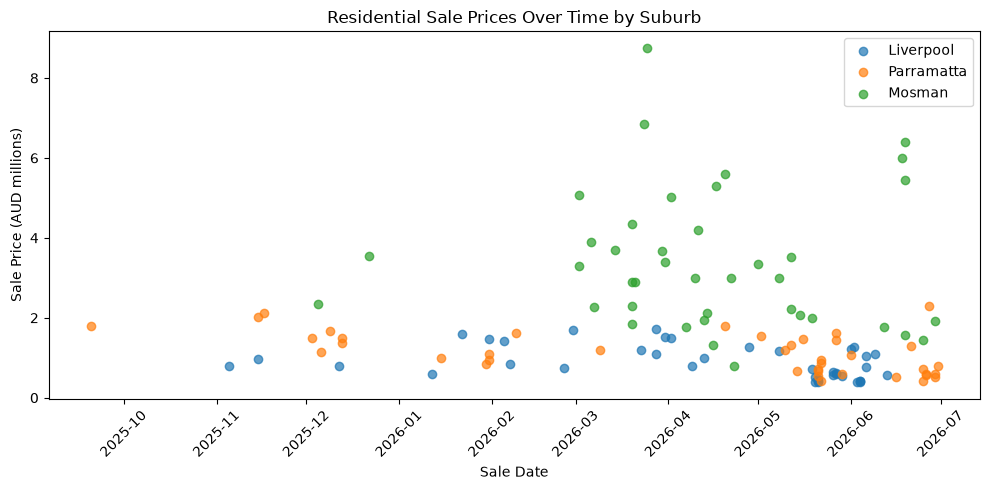

In [15]:
# ============================================================
# SALE PRICE OVER TIME
# ============================================================

plt.figure(figsize=(10, 5))

for suburb in ["Liverpool", "Parramatta", "Mosman"]:
    subset = df[df["suburb"] == suburb]                                 # Suburb observations
    plt.scatter(subset["sale_date"], subset["sale_price"] / 1_000_000,
                alpha=0.7, label=suburb)                                # Individual sales

plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD millions)")
plt.title("Residential Sale Prices Over Time by Suburb")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation.** No clear overall increase or decrease in sale prices is visible across the study period. Differences between suburbs are more pronounced than changes over time, with Mosman consistently containing the highest-value transactions. The temporal pattern should be interpreted cautiously because the observations are unevenly distributed across the study period; 60 of the 120 properties were sold in May and June 2026, while the earlier months contain relatively few observations. Therefore, the dataset does not provide strong evidence of a reliable short-term price trend.

### 2.5 Unusual Observations and Potential Outliers

Potential price outliers were investigated to determine whether extreme observations represented possible data-quality problems or legitimate high-value property transactions. The interquartile range (IQR) method was used as an initial statistical screening tool.


In [16]:
# ============================================================
# POTENTIAL PRICE OUTLIERS
# ============================================================

q1 = df["sale_price"].quantile(0.25)                                   # First quartile
q3 = df["sale_price"].quantile(0.75)                                   # Third quartile
iqr = q3 - q1                                                          # Interquartile range

lower_bound = q1 - 1.5 * iqr                                           # Lower IQR boundary
upper_bound = q3 + 1.5 * iqr                                           # Upper IQR boundary

outliers = df[(df["sale_price"] < lower_bound) |
              (df["sale_price"] > upper_bound)]                        # Flag potential outliers

print("=== IQR Outlier Screening ===")
print(f"Lower bound       : AUD {lower_bound:,.0f}")
print(f"Upper bound       : AUD {upper_bound:,.0f}")
print(f"Potential outliers: {len(outliers)}")

print("\n=== Potential High-Price Outliers ===")
for _, row in outliers.sort_values("sale_price", ascending=False).iterrows():
    print(f"{row['address']:<35} {row['suburb']:<12} "
          f"{row['property_type']:<15} AUD {row['sale_price']:>10,.0f}")  # Property details

=== IQR Outlier Screening ===
Lower bound       : AUD -1,331,250
Upper bound       : AUD 4,198,750
Potential outliers: 11

=== Potential High-Price Outliers ===
26 David Street                     Mosman       House           AUD  8,750,000
88 Shadforth Street                 Mosman       House           AUD  6,850,000
5 Central Avenue                    Mosman       House           AUD  6,399,000
2/63 Muston Street                  Mosman       Apartment-Unit  AUD  6,000,000
3 Glover Street                     Mosman       House           AUD  5,600,000
17 Avenue Road                      Mosman       House           AUD  5,450,000
34 Somerset Street                  Mosman       House           AUD  5,300,000
33 Spofforth Street                 Mosman       House           AUD  5,075,000
22/40 Raglan Street                 Mosman       Apartment-Unit  AUD  5,025,000
1/46B Parriwi Road                  Mosman       Apartment-Unit  AUD  4,350,000
130 Cowles Road                     Mos

In [17]:
# ============================================================
# POTENTIAL OUTLIERS WITHIN EACH SUBURB
# ============================================================

print("=== IQR Outliers Within Each Suburb ===")

for suburb, group in df.groupby("suburb"):
    q1 = group["sale_price"].quantile(0.25)                             # Suburb Q1
    q3 = group["sale_price"].quantile(0.75)                             # Suburb Q3
    iqr = q3 - q1                                                       # Suburb IQR
    upper = q3 + 1.5 * iqr                                              # Upper boundary

    flagged = group[group["sale_price"] > upper]                        # High-price outliers

    print(f"\n{suburb}")
    print(f"  Upper bound       : AUD {upper:,.0f}")
    print(f"  Potential outliers: {len(flagged)}")

    for _, row in flagged.sort_values("sale_price", ascending=False).iterrows():
        print(f"    {row['address']:<32} AUD {row['sale_price']:>10,.0f}")  # Flagged property

=== IQR Outliers Within Each Suburb ===

Liverpool
  Upper bound       : AUD 2,153,125
  Potential outliers: 0

Mosman
  Upper bound       : AUD 7,503,750
  Potential outliers: 1
    26 David Street                  AUD  8,750,000

Parramatta
  Upper bound       : AUD 2,731,875
  Potential outliers: 0


**Observation.** The initial IQR screening across the complete dataset identified 11 potential high-price outliers, all located in Mosman. However, this result is influenced by the substantial price differences between the three suburbs. When the IQR method was applied separately within each suburb, only one property remained a potential outlier: 26 David Street, Mosman, sold for AUD 8.75 million. Liverpool and Parramatta contained no price outliers under the same criterion.

This demonstrates that many observations appearing extreme in the combined dataset are consistent with Mosman's higher-value property market rather than necessarily representing anomalous data. The flagged Mosman property will therefore be retained at this stage and investigated as a legitimate high-value transaction rather than automatically removed.

### 2.6 Initial Feature Expectations

Before engineering additional variables, three factors were expected to have the strongest influence on sale price:

1. **Suburb/location.** Property values were expected to differ substantially between Mosman, Parramatta and Liverpool because each represents a different Sydney housing market. The exploratory analysis already indicates large differences in median prices between these locations.

2. **Property type.** Houses, townhouses and apartments/units were expected to have different price structures because they differ in land ownership, size and dwelling characteristics. The initial analysis also shows clear differences in their sale-price distributions.

3. **Location accessibility.** Properties with stronger access to central Sydney and major transport infrastructure were expected to attract higher values. Although the raw dataset identifies suburb and address, it does not directly quantify spatial accessibility. Therefore, distance-based variables were engineered to represent proximity to the Sydney CBD and the nearest train or metro station

These expectations provide a basis for the subsequent feature-engineering stage and will later be compared with the relationships observed in the engineered dataset and modelling results.

## 2.7 Feature Engineering

The original dataset contained basic property characteristics and suburb names but did not include numerical measures of location or accessibility. I therefore decided to engineer two additional predictors: distance to the Sydney CBD and distance to the nearest train or metro station.

These features were introduced because location and transport accessibility can influence residential property prices and may provide information beyond the broad suburb category. Distance to the CBD provides a consistent measure of proximity to central Sydney, while distance to the nearest station represents access to major rail transport. The objective was to determine whether these engineered variables could add predictive value to the machine-learning models.

Calculating these distances required property-level latitude and longitude coordinates, which were not included in the original dataset. Coordinates were therefore collected and verified before the two distance variables were calculated.

### 2.7.1 Coordinate Collection and Verification

Coordinate collection was completed in three stages. First, automated geocoding was attempted using the OpenStreetMap Nominatim service. Full and simplified address searches produced usable address-level coordinates for only 54 of the 120 properties; three additional results represented suburb-level locations and were excluded because suburb centroids were not considered sufficiently precise.

Because automated geocoding did not provide complete coverage, two separate AI-assisted research exercises were conducted using Claude and ChatGPT. Each exercise used the property addresses and existing listing URLs to search for address-level coordinates and supporting geographic sources. Claude returned coordinates for 34 properties, while ChatGPT returned coordinates for all 120 properties. The ChatGPT results were not accepted solely because they provided complete coverage.

To validate the results, coordinates available from the three methods were matched by property address and compared using the Haversine distance. Of the 54 properties with usable Nominatim coordinates, 50 ChatGPT results were within 500 metres of the Nominatim result. All 34 properties independently located through both Claude and ChatGPT agreed within 100 metres. Cases with differences greater than 500 metres were reviewed individually using the recorded coordinate source and matched address information.

| Coordinate method | Usable property-level coordinates | Validation outcome |
|---|---:|---|
| Python Nominatim automated geocoding | 54 of 120 | Incomplete coverage; suburb-only matches were excluded |
| Claude-assisted research | 34 of 120 | All 34 results agreed with ChatGPT within 100 metres |
| ChatGPT-assisted research | 120 of 120 | 50 of 54 usable Nominatim comparisons agreed within 500 metres; disagreements were individually reviewed |
| Final selected dataset | 120 of 120 | 118 exact-property and 2 approximate-address coordinates |

Following this comparison, the ChatGPT-researched coordinate set was selected because it provided complete property-level coverage, showed strong agreement with the independently obtained Claude results and generally agreed with the usable Nominatim results. The final dataset contained coordinates for all 120 original properties: 118 were classified as `exact_property` and two as `approximate_address`. No suburb or postcode centroid coordinates were retained.

In [18]:
# ============================================================
# LOAD VERIFIED PROPERTY-LEVEL COORDINATES
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv(
    "Data/property_sales_verified_coordinates_final.csv"
)

required_coordinate_columns = [
    "latitude",
    "longitude",
    "coordinate_precision",
    "coordinate_source"
]

missing_columns = [
    column
    for column in required_coordinate_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing coordinate columns: {missing_columns}"
    )

print("=== Verified Coordinate Dataset ===")
print(f"Properties          : {len(df)}")
print(f"Unique addresses    : {df['address'].nunique()}")
print(f"Coordinates present : {df['latitude'].notna().sum()}")
print(f"Coordinates missing : {df['latitude'].isna().sum()}")
print(f"Duplicate addresses : {df['address'].duplicated().sum()}")

print("\n=== Coordinate Precision ===")
print(
    df["coordinate_precision"]
    .value_counts(dropna=False)
    .to_string()
)

=== Verified Coordinate Dataset ===
Properties          : 120
Unique addresses    : 120
Coordinates present : 120
Coordinates missing : 0
Duplicate addresses : 0

=== Coordinate Precision ===
coordinate_precision
exact_property         118
approximate_address      2


**Observation.** The verified dataset contains all 120 original property records with no duplicated addresses or missing coordinates. Of these, 118 coordinates were classified as exact-property matches and two as approximate-address matches. This coverage allows location distances to be calculated without substituting suburb or postcode centroids.

#### 2.7.2 Distance to Sydney CBD

Distance to the Sydney CBD was engineered as a continuous location variable. Using the verified latitude and longitude of each property, straight-line distance to a fixed Sydney CBD reference point was calculated using the Haversine formula. This provides a consistent measure of proximity to the metropolitan centre across all three suburbs.

In [19]:
# ============================================================
# DEFINE HAVERSINE DISTANCE FUNCTION
# ============================================================

def haversine_km(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)                                  # Convert latitude
    lon1 = np.radians(lon1)                                  # Convert longitude
    lat2 = np.radians(lat2)                                  # Convert reference latitude
    lon2 = np.radians(lon2)                                  # Convert reference longitude

    dlat = lat2 - lat1                                       # Latitude difference
    dlon = lon2 - lon1                                       # Longitude difference

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))                  # Distance in kilometres


print("Haversine distance function defined successfully.")

Haversine distance function defined successfully.


In [20]:
# ============================================================
# ENGINEER DISTANCE TO SYDNEY CBD
# ============================================================

CBD_LAT = -33.8688                                                     # Sydney CBD reference
CBD_LON = 151.2093                                                     # Sydney CBD reference

df["distance_to_cbd_km"] = haversine_km(
    df["latitude"],
    df["longitude"],
    CBD_LAT,
    CBD_LON
)                                                                      # Straight-line distance

print("=== Distance to Sydney CBD ===")
print(f"Minimum : {df['distance_to_cbd_km'].min():.2f} km")             # Closest property
print(f"Median  : {df['distance_to_cbd_km'].median():.2f} km")          # Typical distance
print(f"Mean    : {df['distance_to_cbd_km'].mean():.2f} km")            # Average distance
print(f"Maximum : {df['distance_to_cbd_km'].max():.2f} km")             # Furthest property
print(f"Missing : {df['distance_to_cbd_km'].isna().sum()}")             # Completeness

=== Distance to Sydney CBD ===
Minimum : 3.61 km
Median  : 19.71 km
Mean    : 17.61 km
Maximum : 29.19 km
Missing : 0


In [21]:
# ============================================================
# DISTANCE TO CBD BY SUBURB
# ============================================================

print("=== Distance to Sydney CBD by Suburb ===")

for suburb, group in df.groupby("suburb"):
    print(f"\n{suburb} (n={len(group)})")
    print(f"  Mean    : {group['distance_to_cbd_km'].mean():.2f} km")       # Average distance
    print(f"  Median  : {group['distance_to_cbd_km'].median():.2f} km")     # Typical distance
    print(f"  Minimum : {group['distance_to_cbd_km'].min():.2f} km")        # Closest property
    print(f"  Maximum : {group['distance_to_cbd_km'].max():.2f} km")        # Furthest property

=== Distance to Sydney CBD by Suburb ===

Liverpool (n=40)
  Mean    : 27.89 km
  Median  : 27.82 km
  Minimum : 26.61 km
  Maximum : 29.19 km

Mosman (n=40)
  Mean    : 5.40 km
  Median  : 5.61 km
  Minimum : 3.61 km
  Maximum : 7.08 km

Parramatta (n=40)
  Mean    : 19.54 km
  Median  : 19.71 km
  Minimum : 18.38 km
  Maximum : 20.69 km


**Observation.** Distance to the Sydney CBD shows a clear geographic pattern across the three suburbs. Mosman properties are closest to the CBD, with a median distance of 5.61 km, followed by Parramatta at 19.71 km and Liverpool at 27.82 km. This confirms that the engineered variable captures meaningful location differences between the selected property markets and may provide additional information for predicting sale prices.

#### 2.7.3 Distance to Nearest Train Station

Accessibility to rail transport was represented by the straight-line distance from each property to its nearest train or metro station. Station locations were obtained from Transport for NSW public transport data. Each property's verified coordinates were compared with the available station coordinates using the Haversine distance, and the minimum distance was retained together with the corresponding station name.

In [22]:
# ============================================================
# LOAD PUBLIC TRANSPORT STOP DATA
# ============================================================

stops = pd.read_csv(
    "Data/full_greater_sydney_gtfs_static_0/stops.txt"
)                                                                       # TfNSW GTFS stops

print("=== GTFS Stop Dataset ===")
print(f"Stops     : {len(stops)}")                                      # Total stop records
print(f"Variables : {stops.shape[1]}")                                  # Available fields

print("\n=== Stop Variables ===")
print(stops.columns.tolist())

=== GTFS Stop Dataset ===
Stops     : 171050
Variables : 10

=== Stop Variables ===
['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'wheelchair_boarding', 'level_id', 'platform_code']


C:\Users\nixis\AppData\Local\Temp\ipykernel_20220\2137251449.py:5: DtypeWarning: Columns (0: platform_code) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(


In [23]:
# ============================================================
# INSPECT GTFS STOP TYPES
# ============================================================

print("=== GTFS Location Types ===")
print(stops["location_type"].value_counts(dropna=False).sort_index())    # Stop type counts

print("\n=== Example Parent Stations ===")
print(
    stops.loc[stops["location_type"] == 1,
              ["stop_id", "stop_name", "stop_lat", "stop_lon"]]
    .head(20)
    .to_string(index=False)
)                                                                       # Inspect station records

=== GTFS Location Types ===
location_type
1.0    78020
2.0      954
3.0     1479
NaN    90597
Name: count, dtype: int64

=== Example Parent Stations ===
stop_id                        stop_name   stop_lat   stop_lon
 253330                    Kiama Station -34.672667 150.854455
 253420               Gerringong Station -34.744761 150.817601
 253510                    Berry Station -34.780308 150.696616
 254110                Bomaderry Station -34.853839 150.609754
 257810                Bundanoon Station -34.655969 150.299499
 257910                 Wingello Station -34.692224 150.158234
 257920                  Penrose Station -34.672294 150.212078
 257940                  Marulan Station -34.709523 150.006120
 257950                  Tallong Station -34.718323 150.086321
 257984           Exeter Oval, Exeter Rd -34.612305 150.316693
 258010                 Goulburn Station -34.758300 149.719354
G257735      Leighton Gardens, Argyle St -34.549002 150.372169
G257926 Tallong General Stor

In [24]:
# ============================================================
# INSPECT GTFS ROUTE TYPES
# ============================================================

routes = pd.read_csv(
    "Data/full_greater_sydney_gtfs_static_0/routes.txt"
)                                                                       # TfNSW route data

print("=== Route Dataset ===")
print(f"Routes    : {len(routes)}")
print(f"Variables : {routes.shape[1]}")

print("\n=== Route Variables ===")
print(routes.columns.tolist())

print("\n=== Route Type Counts ===")
print(routes["route_type"].value_counts(dropna=False).sort_index())     # Transport modes

print("\n=== Example Routes ===")
print(
    routes[["route_id", "route_short_name",
            "route_long_name", "route_type"]]
    .head(30)
    .to_string(index=False)
)                                                                       # Inspect route categories

=== Route Dataset ===
Routes    : 10181
Variables : 9

=== Route Variables ===
['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_color', 'route_text_color', 'exact_times']

=== Route Type Counts ===
route_type
2        17
4        24
106      27
204     163
205     116
401       1
700    1149
712    8624
714      54
900       6
Name: count, dtype: int64

=== Example Routes ===
      route_id route_short_name                                              route_long_name  route_type
 1-SC0-1-sj2-1             SC01                                           Kiama to Bomaderry         700
 1-SH1-0-sj2-2            SH100                                        Moss Vale to Goulburn         700
11-22T-2-sj2-1             22T2                  East Hills, then all stations to Leppington         714
11-400-1-sj2-1             4001                          Penrith Station to McCarthy College         712
11-400-2-sj2-1             4002     Swallow D

In [25]:
# ============================================================
# INSPECT ROUTES BY TRANSPORT TYPE
# ============================================================

for route_type in sorted(routes["route_type"].unique()):
    subset = routes[routes["route_type"] == route_type]

    print(f"\n=== Route Type {route_type} (n={len(subset)}) ===")
    print(
        subset[["route_short_name", "route_long_name"]]
        .head(10)
        .to_string(index=False)
    )                                                                   # Example services


=== Route Type 2 (n=17) ===
route_short_name                       route_long_name
             BMT                   Blue Mountains Line
             CCN      Central Coast and Newcastle Line
             SCO                      South Coast Line
              T1       T1 North Shore and Western Line
              T1       T1 North Shore and Western Line
              T2     T2 Leppington and Inner West Line
              T3      T3 Liverpool and Inner West Line
              T4 T4 Eastern Suburbs and Illawarra Line
              T5                    T5 Cumberland Line
              T6        T6 Lidcombe and Bankstown Line

=== Route Type 4 (n=24) ===
route_short_name                  route_long_name
            BRKL              BRKL Brooklyn Ferry
            BUNC              BUNC Bundeena Ferry
            CCLC             CCLC Lane Cove Ferry
            CCSH          CCSH Shark Island Ferry
            CCTZ           CCTZ Taronga Zoo Ferry
            CCWB           CCWB Watso

In [26]:
# ============================================================
# IDENTIFY TRAIN AND METRO STOPS
# ============================================================

trips = pd.read_csv(
    "Data/full_greater_sydney_gtfs_static_0/trips.txt",
    low_memory=False
)                                                                       # GTFS trips

stop_times = pd.read_csv(
    "Data/full_greater_sydney_gtfs_static_0/stop_times.txt",
    low_memory=False
)                                                                       # GTFS trip-stop links

rail_routes = routes.loc[
    routes["route_type"].isin([2, 401]), "route_id"
]                                                                       # Train + metro routes

rail_trips = trips.loc[
    trips["route_id"].isin(rail_routes), "trip_id"
]                                                                       # Trips on rail routes

rail_stop_ids = stop_times.loc[
    stop_times["trip_id"].isin(rail_trips), "stop_id"
].unique()                                                              # Stops served by rail

print("=== Train and Metro Network ===")
print(f"Rail/metro routes : {len(rail_routes)}")                         # Relevant routes
print(f"Rail/metro trips  : {len(rail_trips)}")                          # Relevant trips
print(f"Rail stop records : {len(rail_stop_ids)}")                       # Served stops

=== Train and Metro Network ===
Rail/metro routes : 18
Rail/metro trips  : 70104
Rail stop records : 748


In [27]:
# ============================================================
# CONSOLIDATE RAIL STOPS INTO UNIQUE STATIONS
# ============================================================

rail_stops = stops[
    stops["stop_id"].isin(rail_stop_ids)
].copy()                                                                # Rail-served stops

rail_stops["station_id"] = rail_stops["parent_station"].fillna(
    rail_stops["stop_id"]
)                                                                       # Parent station identifier

station_ids = rail_stops["station_id"].dropna().unique()                 # Unique stations

rail_stations = stops[
    stops["stop_id"].isin(station_ids)
][["stop_id", "stop_name", "stop_lat", "stop_lon"]].copy()               # Station coordinates

rail_stations = rail_stations.drop_duplicates("stop_id")                 # Remove duplicates

print("=== Unique Train and Metro Stations ===")
print(f"Stations : {len(rail_stations)}")

print("\n=== Example Stations ===")
print(
    rail_stations.head(20).to_string(index=False)
)

=== Unique Train and Metro Stations ===
Stations : 308

=== Example Stations ===
stop_id                    stop_name   stop_lat   stop_lon
 253330                Kiama Station -34.672667 150.854455
 253420           Gerringong Station -34.744761 150.817601
 253510                Berry Station -34.780308 150.696616
 254110            Bomaderry Station -34.853839 150.609754
 257810            Bundanoon Station -34.655969 150.299499
 257910             Wingello Station -34.692224 150.158234
 257920              Penrose Station -34.672294 150.212078
 257940              Marulan Station -34.709523 150.006120
 257950              Tallong Station -34.718323 150.086321
 258010             Goulburn Station -34.758300 149.719354
 211310 Macquarie University Station -33.777282 151.118267
 211340       Macquarie Park Station -33.785080 151.128374
 212210             Eastwood Station -33.790301 151.082297
 214710          Seven Hills Station -33.774351 150.936123
 214810            Blacktown Stati

In [28]:
# ============================================================
# CALCULATE DISTANCE TO NEAREST STATION
# ============================================================

def nearest_station(row):
    distances = haversine_km(
        row["latitude"],
        row["longitude"],
        rail_stations["stop_lat"],
        rail_stations["stop_lon"]
    )                                                                   # Distance to all stations

    nearest_idx = np.argmin(distances)                                  # Closest station
    nearest = rail_stations.iloc[nearest_idx]

    return pd.Series([
        nearest["stop_name"],
        distances.iloc[nearest_idx]
    ])

df[["nearest_station", "distance_to_station_km"]] = df.apply(
    nearest_station,
    axis=1
)                                                                       # Add station features

print("=== Distance to Nearest Train/Metro Station ===")
print(f"Minimum : {df['distance_to_station_km'].min():.2f} km")
print(f"Median  : {df['distance_to_station_km'].median():.2f} km")
print(f"Mean    : {df['distance_to_station_km'].mean():.2f} km")
print(f"Maximum : {df['distance_to_station_km'].max():.2f} km")
print(f"Missing : {df['distance_to_station_km'].isna().sum()}")

=== Distance to Nearest Train/Metro Station ===
Minimum : 0.24 km
Median  : 1.53 km
Mean    : 1.84 km
Maximum : 4.49 km
Missing : 0


In [29]:
# ============================================================
# NEAREST STATION DISTANCE BY SUBURB
# ============================================================

print("=== Distance to Nearest Station by Suburb ===")

for suburb, group in df.groupby("suburb"):
    print(f"\n{suburb} (n={len(group)})")
    print(f"  Mean   : {group['distance_to_station_km'].mean():.2f} km")
    print(f"  Median : {group['distance_to_station_km'].median():.2f} km")

print("\n=== Example Nearest Stations ===")
print(
    df[["address", "suburb", "nearest_station",
        "distance_to_station_km"]]
    .head(15)
    .to_string(index=False)
)

=== Distance to Nearest Station by Suburb ===

Liverpool (n=40)
  Mean   : 1.35 km
  Median : 1.42 km

Mosman (n=40)
  Mean   : 3.15 km
  Median : 3.19 km

Parramatta (n=40)
  Mean   : 1.01 km
  Median : 1.16 km

=== Example Nearest Stations ===
            address suburb        nearest_station  distance_to_station_km
     17 Avenue Road Mosman  Milsons Point Station                2.327321
   5 Central Avenue Mosman Victoria Cross Station                4.226654
     41 Lang Street Mosman Victoria Cross Station                3.025433
  6 Countess Street Mosman Victoria Cross Station                3.198137
    3 Glover Street Mosman Victoria Cross Station                2.900075
 34 Somerset Street Mosman  Milsons Point Station                2.711780
    130 Cowles Road Mosman Victoria Cross Station                3.417448
 44 Musgrave Street Mosman  Milsons Point Station                2.116957
   27 Bardwell Road Mosman Victoria Cross Station                2.909161
88 Shadforth S

**Observation.** Access to train and metro stations varies across the three property markets. Parramatta properties have the shortest median distance to a station (1.16 km), followed by Liverpool (1.42 km), while Mosman properties are substantially further away (3.19 km). Mosman properties were generally matched to stations such as Victoria Cross, Milsons Point and North Sydney. This pattern is geographically reasonable and indicates that the engineered variable captures differences in rail accessibility that are not represented by suburb alone.

### 2.8 Engineered Feature Exploration

The engineered distance variables were examined against sale price to determine whether their relationships were consistent with the expectations established before feature engineering. Because the three suburbs represent distinct property markets, both overall and within-suburb relationships were considered to avoid interpreting differences between suburbs as direct effects of distance.

In [30]:
# ============================================================
# ENGINEERED FEATURE CORRELATIONS
# ============================================================

print("=== Pearson Correlations with Sale Price ===")
print(f"Distance to CBD     : {df['sale_price'].corr(df['distance_to_cbd_km'], method='pearson'):.3f}")          # Overall correlation
print(f"Distance to station : {df['sale_price'].corr(df['distance_to_station_km'], method='pearson'):.3f}")      # Overall correlation

=== Pearson Correlations with Sale Price ===
Distance to CBD     : -0.699
Distance to station : 0.662


In [31]:
# ============================================================
# PEARSON CORRELATIONS WITHIN EACH SUBURB
# ============================================================

print("=== Within-Suburb Pearson Correlations with Sale Price ===")

for suburb, group in df.groupby("suburb"):
    print(f"\n{suburb}")
    print(f"  Distance to CBD     : {group['sale_price'].corr(group['distance_to_cbd_km'], method='pearson'):.3f}")      # CBD relationship
    print(f"  Distance to station : {group['sale_price'].corr(group['distance_to_station_km'], method='pearson'):.3f}")  # Station relationship

=== Within-Suburb Pearson Correlations with Sale Price ===

Liverpool
  Distance to CBD     : 0.571
  Distance to station : 0.695

Mosman
  Distance to CBD     : -0.124
  Distance to station : -0.037

Parramatta
  Distance to CBD     : -0.258
  Distance to station : 0.571


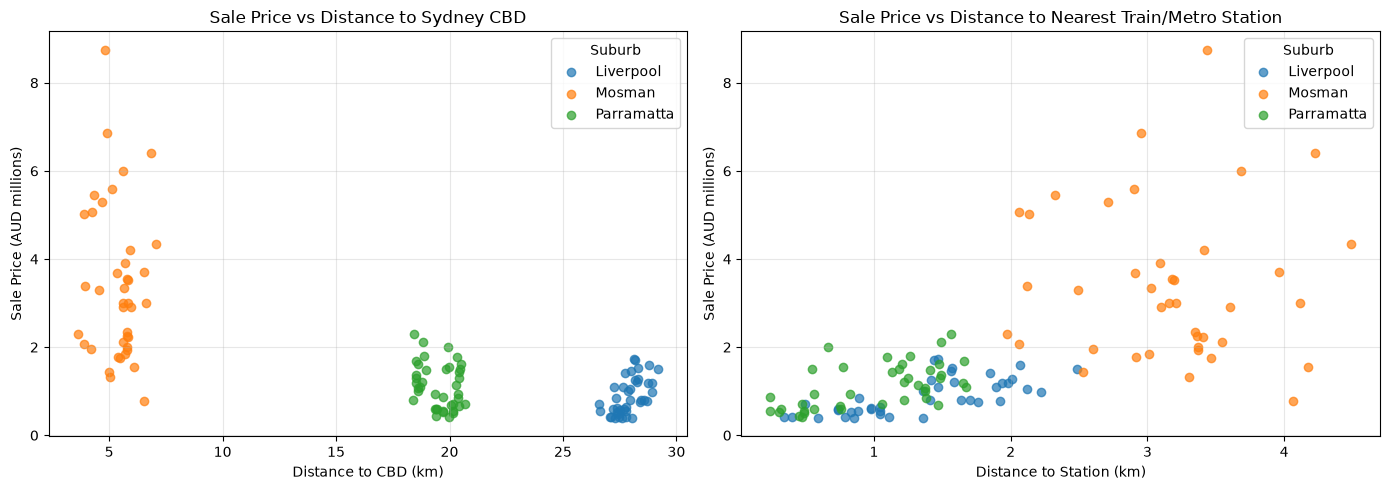

In [32]:
# ============================================================
# ENGINEERED FEATURES VS SALE PRICE
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for suburb, group in df.groupby("suburb"):
    axes[0].scatter(
        group["distance_to_cbd_km"],
        group["sale_price"] / 1_000_000,
        label=suburb,
        alpha=0.7
    )                                                                  # CBD distance

    axes[1].scatter(
        group["distance_to_station_km"],
        group["sale_price"] / 1_000_000,
        label=suburb,
        alpha=0.7
    )                                                                  # Station distance

axes[0].set_title("Sale Price vs Distance to Sydney CBD")
axes[0].set_xlabel("Distance to CBD (km)")
axes[0].set_ylabel("Sale Price (AUD millions)")
axes[0].grid(alpha=0.3)
axes[0].legend(title="Suburb")

axes[1].set_title("Sale Price vs Distance to Nearest Train/Metro Station")
axes[1].set_xlabel("Distance to Station (km)")
axes[1].set_ylabel("Sale Price (AUD millions)")
axes[1].grid(alpha=0.3)
axes[1].legend(title="Suburb")

plt.tight_layout()
plt.show()

**Observation.** The engineered location variables show substantial overall correlations with sale price, with distance to the CBD negatively correlated with price (r = -0.699) and distance to the nearest train or metro station positively correlated with price (r = 0.662). However, the scatter plots show that these overall relationships are strongly influenced by differences between the three suburb markets.

For CBD distance, Mosman forms a distinct cluster of high-value properties close to the CBD, while Parramatta and Liverpool form progressively more distant and generally lower-priced clusters. The within-suburb correlations are considerably less consistent, indicating that CBD distance largely captures broader location differences rather than a uniform relationship with price across individual properties.

Similarly, the positive overall relationship between station distance and price does not support the initial expectation that greater rail accessibility would necessarily correspond with higher prices. This pattern is influenced by high-value Mosman properties generally being farther from train or metro stations than properties in Parramatta and Liverpool. Overall, the engineered features provide useful location information, but their relationships with price are strongly dependent on the underlying suburb market.

In [33]:
# ============================================================
# RETAIN UNREPORTED PARKING AS MISSING
# ============================================================

unreported_parking = [
    "41 Lang Street",
    "4/2 Musgrave Street",
    "625/88 Church Street",
    "841/180 George Street"
]

df.loc[
    df["address"].isin(unreported_parking),
    "parking_spaces"
] = np.nan                                                       # Restore unavailable values

print("=== Parking-Space Verification ===")
print(f"Unreported parking values : {df['parking_spaces'].isna().sum()}")
print(f"Reported parking range    : {df['parking_spaces'].min():.0f} to "
      f"{df['parking_spaces'].max():.0f} spaces")

=== Parking-Space Verification ===
Unreported parking values : 4
Reported parking range    : 1 to 4 spaces


**Observation.** Parking-space information was unavailable for four properties. These values were retained as missing rather than interpreted as zero because the absence of a reported parking feature does not confirm that no parking exists. The missing values will be imputed during model training using the median parking count for the corresponding property type, with an additional indicator identifying originally missing values.

### 2.9 Export the Final Engineered Dataset

After completing the feature-engineering and exploratory analysis stages, the final dataset was exported for use in Part 3. The exported dataset preserves the original property records and includes the verified coordinates and engineered location variables.

In [34]:
# ============================================================
# EXPORT FINAL ENGINEERED DATASET
# ============================================================

output_file = "sydney_property_sales_engineered_final.csv"

df.to_csv(
    output_file,
    index=False,          # Do not export the DataFrame index
    na_rep="NA"           # Clearly represent unavailable values
)

print("=== Final Dataset Exported ===")
print(f"File    : {output_file}")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

=== Final Dataset Exported ===
File    : sydney_property_sales_engineered_final.csv
Rows    : 120
Columns : 23


In [35]:
# ============================================================
# VERIFY EXPORTED DATASET
# ============================================================

df_export_check = pd.read_csv(
    "sydney_property_sales_engineered_final.csv",
    na_values=["NA"]
)

print("=== Export Verification ===")
print(f"Rows           : {df_export_check.shape[0]}")
print(f"Columns        : {df_export_check.shape[1]}")
print(f"Duplicate rows : {df_export_check.duplicated().sum()}")
print(f"Missing target : {df_export_check['sale_price'].isna().sum()}")

# Select engineered variables
engineered_preview = df_export_check[
    [
        "latitude",
        "longitude",
        "distance_to_cbd_km",
        "nearest_station",
        "distance_to_station_km"
    ]
].head()

print("\n=== Engineered Variables ===")
print(engineered_preview.to_string(index=False))

=== Export Verification ===
Rows           : 120
Columns        : 23
Duplicate rows : 0
Missing target : 0

=== Engineered Variables ===
  latitude  longitude  distance_to_cbd_km        nearest_station  distance_to_station_km
-33.835813 151.233892            4.314134  Milsons Point Station                2.327321
-33.813734 151.242873            6.863412 Victoria Cross Station                4.226654
-33.822454 151.234491            5.654212 Victoria Cross Station                3.025433
-33.821019 151.235567            5.840568 Victoria Cross Station                3.198137
-33.828620 151.236806            5.139393 Victoria Cross Station                2.900075


## Part 3. Model Development and Evaluation

This section develops and evaluates regression models for predicting residential sale prices. The final engineered dataset is used, with `sale_price` defined as the target variable. Predictor selection focuses on property characteristics, location, accessibility and sale method. Administrative identifiers, descriptive text, URLs and coordinate-verification fields are excluded because they are unsuitable as direct predictive inputs.

In [36]:
# ============================================================
# LOAD THE FINAL ENGINEERED DATASET
# ============================================================

import pandas as pd
import numpy as np

df_model = pd.read_csv(
    "sydney_property_sales_engineered_final.csv",
    na_values=["NA"]
)

print("=== Modelling Dataset ===")
print(f"Rows           : {df_model.shape[0]}")
print(f"Columns        : {df_model.shape[1]}")
print(f"Missing target : {df_model['sale_price'].isna().sum()}")
print(f"Duplicate rows : {df_model.duplicated().sum()}")

print("\n=== Dataset Variables ===")
for number, column in enumerate(df_model.columns, start=1):
    print(f"{number:>2}. {column:<25} {str(df_model[column].dtype)}")

=== Modelling Dataset ===
Rows           : 120
Columns        : 23
Missing target : 0
Duplicate rows : 0

=== Dataset Variables ===
 1. address                   str
 2. suburb                    str
 3. postcode                  int64
 4. sale_price                int64
 5. sale_date                 str
 6. property_type             str
 7. bedrooms                  int64
 8. bathrooms                 int64
 9. parking_spaces            float64
10. land_size_m2              float64
11. sale_method               str
12. property_description      str
13. source                    str
14. listing_url               str
15. full_address              str
16. geocode_level             float64
17. latitude                  float64
18. longitude                 float64
19. coordinate_precision      str
20. coordinate_source         str
21. distance_to_cbd_km        float64
22. nearest_station           str
23. distance_to_station_km    float64


### 3.1 Target and Predictor Selection

The target variable is `sale_price`. Nine predictors were selected to represent property size and capacity, property category, market location, transport accessibility and sale method. Address-related identifiers, listing URLs, descriptions, raw coordinate-verification fields and data-source fields were excluded because they either uniquely identify individual records or are not appropriate inputs for a generalisable prediction model.

In [37]:
# ============================================================
# DEFINE TARGET AND PREDICTORS
# ============================================================

target = "sale_price"

numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "land_size_m2",
    "distance_to_cbd_km",
    "distance_to_station_km"
]

categorical_features = [
    "suburb",
    "property_type",
    "sale_method"
]

selected_features = numeric_features + categorical_features

X = df_model[selected_features].copy()
y = df_model[target].copy()

print("=== Model Variables ===")
print(f"Target               : {target}")
print(f"Number of predictors : {len(selected_features)}")
print(f"Input shape          : {X.shape}")

print("\nNumeric predictors:")
for feature in numeric_features:
    print(f"  {feature}")

print("\nCategorical predictors:")
for feature in categorical_features:
    print(f"  {feature}")

=== Model Variables ===
Target               : sale_price
Number of predictors : 9
Input shape          : (120, 9)

Numeric predictors:
  bedrooms
  bathrooms
  parking_spaces
  land_size_m2
  distance_to_cbd_km
  distance_to_station_km

Categorical predictors:
  suburb
  property_type
  sale_method


### 3.2 Training and Test Split

The dataset was divided into 80% training data and 20% test data. The split was stratified by suburb to maintain representation of Mosman, Parramatta and Liverpool in both subsets. A fixed random state was used to make the results reproducible. The test data were reserved for final model evaluation and were not used during model training.

In [38]:
# ============================================================
# TRAINING AND TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df_model["suburb"]
)

print("=== Training and Test Split ===")
print(f"Training observations : {X_train.shape[0]}")
print(f"Test observations     : {X_test.shape[0]}")
print(f"Training proportion   : {X_train.shape[0] / len(X):.1%}")
print(f"Test proportion       : {X_test.shape[0] / len(X):.1%}")

print("\n=== Suburb Distribution ===")
print("Training:")
print(X_train["suburb"].value_counts().sort_index().to_string())

print("\nTest:")
print(X_test["suburb"].value_counts().sort_index().to_string())

=== Training and Test Split ===
Training observations : 96
Test observations     : 24
Training proportion   : 80.0%
Test proportion       : 20.0%

=== Suburb Distribution ===
Training:
suburb
Liverpool     32
Mosman        32
Parramatta    32

Test:
suburb
Liverpool     8
Mosman        8
Parramatta    8


### 3.3 Data Preprocessing

Preprocessing was performed through a pipeline fitted only to the training data. Missing numerical values were replaced using the median calculated from the training subset, preventing information leakage from the test data. Numerical predictors were standardised, while categorical predictors were converted into binary variables using one-hot encoding. Unknown categories were ignored so that the pipeline could process new property records submitted through the application.

In [39]:
# ============================================================
# PROPERTY-TYPE NUMERIC IMPUTER
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin

class PropertyTypeNumericImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()                                                # Protect original data

        self.columns_ = [
            "land_size_m2",
            "parking_spaces"
        ]                                                           # Variables to impute

        self.group_medians_ = {
            column: X.groupby("property_type")[column].median().to_dict()
            for column in self.columns_
        }                                                           # Medians by property type

        self.overall_medians_ = (
            X[self.columns_].median().to_dict()
        )                                                           # Fallback medians

        return self

    def transform(self, X):
        X = X.copy()                                                # Protect input data

        for column in self.columns_:
            X[f"{column}_missing"] = (
                X[column].isna().astype(int)
            )                                                       # Record original missingness

            matched_medians = X["property_type"].map(
                self.group_medians_[column]
            )                                                       # Match property-type median

            X[column] = (
                X[column]
                .fillna(matched_medians)
                .fillna(self.overall_medians_[column])
            )                                                       # Impute missing values

        return X

In [40]:
# ============================================================
# VARIABLE GROUPS AFTER NUMERIC IMPUTATION
# ============================================================

numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "land_size_m2",
    "distance_to_cbd_km",
    "distance_to_station_km"
]

categorical_features = [
    "suburb",
    "property_type",
    "sale_method"
]

missing_indicators = [
    "land_size_m2_missing",
    "parking_spaces_missing"
]

In [41]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())                                    # Standardise numerical inputs
])

categorical_transformer = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",                                # Accept unseen categories
            drop="first"                                            # Remove reference categories
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),                                                              # Process numerical variables
    (
        "categorical",
        categorical_transformer,
        categorical_features
    ),                                                              # Encode categorical variables
    (
        "missing",
        "passthrough",
        missing_indicators
    )                                                               # Retain missing-value indicators
])

print("=== Preprocessing Strategy ===")
print("Land-size imputation : median within property type")
print("Parking imputation   : median within property type")
print("Imputation source    : training data only")
print("Missing indicators   : land size and parking")
print("Numerical variables  : standardised")
print("Categorical variables: one-hot encoded; first category dropped")

=== Preprocessing Strategy ===
Land-size imputation : median within property type
Parking imputation   : median within property type
Imputation source    : training data only
Missing indicators   : land size and parking
Numerical variables  : standardised
Categorical variables: one-hot encoded; first category dropped


**Observation.** Missing land size and parking values were imputed using the median for the corresponding property type. For example, a missing apartment land size was replaced using the median calculated from apartments in the relevant training subset. Missing-value indicators were retained so that the models could distinguish reported values from imputed values. The imputation was incorporated into the modelling pipeline to prevent information from the test data or validation folds entering model training.

In [42]:
# ============================================================
# TRAINING-SET MEDIANS BY PROPERTY TYPE
# ============================================================

training_medians = (
    X_train.groupby("property_type")[
        ["land_size_m2", "parking_spaces"]
    ]
    .median()
    .sort_index()
)                                                                   # Training data only

print("=== Training-Set Medians by Property Type ===")

for property_type, row in training_medians.iterrows():
    print(f"\n{property_type}")
    print(f"  Land size : {row['land_size_m2']:,.1f} m²")               # Land-size median
    print(f"  Parking   : {row['parking_spaces']:,.1f} spaces")         # Parking median

=== Training-Set Medians by Property Type ===

Apartment-Unit
  Land size : 105.0 m²
  Parking   : 1.0 spaces

House
  Land size : 537.5 m²
  Parking   : 2.0 spaces

Townhouse
  Land size : 176.0 m²
  Parking   : 2.0 spaces


**Observation.** The training-set medians differ by property type. Median land size ranges from 105.0 m² for apartments to 537.5 m² for houses, while median parking ranges from one space for apartments to two spaces for houses and townhouses. These differences support property-type-specific imputation instead of applying one overall value to every property.

### 3.4 Model Evaluation Strategy

Model performance was assessed using five-fold cross-validation on the training data, followed by final evaluation on the reserved test set. The evaluation used Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and the coefficient of determination (R²), consistent with the regression evaluation measures introduced in the course.

MAE represents the average absolute difference between actual and predicted sale prices. MSE gives greater weight to large prediction errors by squaring them, while RMSE converts this measure back into Australian dollars. R² measures the proportion of sale-price variation explained by the model. Better performance is indicated by lower MAE, MSE and RMSE values and a higher R² value.

### 3.5 Median-Price Baseline

A baseline model was established using the median sale price from each training fold. This model predicts the same value for every property and does not learn relationships between the predictors and sale price. It provides a minimum benchmark that the machine-learning regression models should improve upon.

In [43]:
# ============================================================
# CROSS-VALIDATION SETUP
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyRegressor

cv = StratifiedKFold(
    n_splits=5,                                                     # Five validation folds
    shuffle=True,                                                   # Randomise observations
    random_state=42                                                 # Reproducible folds
)

cv_splits = list(
    cv.split(X_train, X_train["suburb"])                            # Preserve suburb proportions
)

In [44]:
# ============================================================
# MEDIAN-PRICE BASELINE
# ============================================================

baseline_pipeline = Pipeline([
    ("numeric_imputer", PropertyTypeNumericImputer()),              # Impute within property type
    ("preprocessor", preprocessor),                                 # Scale and encode predictors
    ("model", DummyRegressor(strategy="median"))                    # Predict training median
])

scoring = {
    "mae": "neg_mean_absolute_error",                               # Mean absolute error
    "mse": "neg_mean_squared_error",                                # Mean squared error
    "rmse": "neg_root_mean_squared_error",                          # Root mean squared error
    "r2": "r2"                                                      # Explained price variation
}

baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                   # Use the same five folds
    scoring=scoring                                                 # Calculate all four metrics
)

baseline_results = {
    "Model": "Median Baseline",
    "MAE": -baseline_cv["test_mae"].mean(),                         # Average fold MAE
    "MSE": -baseline_cv["test_mse"].mean(),                         # Average fold MSE
    "RMSE": -baseline_cv["test_rmse"].mean(),                       # Average fold RMSE
    "R2": baseline_cv["test_r2"].mean()                             # Average fold R²
}

print("=== Median Baseline: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {baseline_results['MAE']:,.0f}")
print(f"Mean MSE  : {baseline_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {baseline_results['RMSE']:,.0f}")
print(f"Mean R²   : {baseline_results['R2']:.3f}")

=== Median Baseline: 5-Fold Cross-Validation ===
Mean MAE  : AUD 1,101,769
Mean MSE  : 3,061,184,755,523
Mean RMSE : AUD 1,716,905
Mean R²   : -0.122


**Observation.** Across the five validation folds, the median baseline produced a mean MAE of AUD 1,101,769, a mean RMSE of AUD 1,716,905 and a mean R² of −0.122. In each fold, the model predicted the median sale price calculated from that fold’s training observations for every validation property. The negative mean R² indicates that these median-based predictions did not explain the variation in sale prices. These results provide the minimum benchmark for evaluating the trained regression models.

#### 3.5.1 Model Selection and Expected Performance

Three regression models were selected to represent different modelling approaches. Multiple Linear Regression provides an interpretable statistical model and establishes whether sale prices can be explained through additive linear relationships. Its main strength is coefficient interpretation, although it may underfit if property characteristics interact or influence price nonlinearly.

Random Forest represents bagging ensemble learning. It can capture nonlinear relationships and interactions without requiring a predetermined functional form. This is suitable for a dataset containing mixed numerical and categorical property characteristics. However, its greater complexity creates a risk of overfitting the relatively small dataset, and its predictions are less directly interpretable than Linear Regression.

AdaBoost represents boosting ensemble learning. It sequentially focuses on properties with larger errors, which may improve difficult predictions. However, this focus can make it sensitive to unusual or high-priced properties, particularly because the dataset contains only 120 observations and a wide sale-price range.

Before training, Random Forest was expected to perform best because property prices were likely to depend on nonlinear interactions among suburb, property type, bedrooms, land size and accessibility. AdaBoost was expected to provide competitive performance but potentially be affected by unusual sales. Linear Regression was expected to be easier to interpret but less accurate if its linear assumptions were too restrictive.

### Rationale and Expected Performance of the Selected Regression Models

| Approach | Reason for Selection and Strengths | Limitations | Expected Performance |
|---|---|---|---|
| **Median Baseline (Minimum Benchmark)** | Predicts the training-fold median sale price for every validation property. It provides a minimum benchmark that each trained model should exceed. | Does not use property characteristics or learn relationships between predictors and sale price. | Expected to perform worst and provide a reference for evaluating the three trained models. |
| **Multiple Linear Regression (Parametric Benchmark)** | Provides an interpretable statistical approach. Its coefficients indicate the direction and relative strength of associations between predictors and sale price. | Assumes additive linear relationships and may not capture interactions among location, dwelling characteristics and accessibility. It may also be affected by correlated predictors and extreme prices. | Expected to be the most interpretable but least accurate of the three trained models. |
| **Random Forest Regression (Bagging Ensemble)** | Combines multiple decision trees to capture nonlinear relationships and feature interactions. Tree averaging reduces the instability of individual trees and is suitable for mixed property and location variables. | Less directly interpretable and may overfit because the dataset contains only 120 properties. | Expected to perform best because property prices likely depend on nonlinear interactions among location, property type, size and accessibility. |
| **AdaBoost Regression (Boosting Ensemble)** | Sequentially focuses on observations with larger previous errors and can capture nonlinear relationships. | May focus too strongly on unusual high-price properties and overfit a small dataset with a wide price range. | Expected to outperform Linear Regression and be competitive with Random Forest, but potentially be less stable around extreme sales. |

Based on these considerations, **Random Forest was expected to perform best**, while AdaBoost was expected to be competitive and Multiple Linear Regression to provide the clearest interpretation. The Median Baseline was expected to perform worst because it does not use property-level information.

### 3.6 Multiple Linear Regression

Multiple Linear Regression was developed as the first predictive model. It estimates sale price as a linear combination of the selected property, location and accessibility predictors. The complete preprocessing and imputation process was included in the pipeline and fitted separately within each cross-validation fold.

In [45]:
# ============================================================
# MULTIPLE LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("numeric_imputer", PropertyTypeNumericImputer()),              # Impute within property type
    ("preprocessor", preprocessor),                                 # Scale and encode predictors
    ("model", LinearRegression())                                   # Fit linear regression
])

linear_cv = cross_validate(
    linear_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                   # Same five validation folds
    scoring=scoring                                                 # Same four metrics
)

linear_results = {
    "Model": "Linear Regression",
    "MAE": -linear_cv["test_mae"].mean(),                           # Average fold MAE
    "MSE": -linear_cv["test_mse"].mean(),                           # Average fold MSE
    "RMSE": -linear_cv["test_rmse"].mean(),                         # Average fold RMSE
    "R2": linear_cv["test_r2"].mean()                               # Average fold R²
}

print("=== Linear Regression: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {linear_results['MAE']:,.0f}")
print(f"Mean MSE  : {linear_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {linear_results['RMSE']:,.0f}")
print(f"Mean R²   : {linear_results['R2']:.3f}")

=== Linear Regression: 5-Fold Cross-Validation ===
Mean MAE  : AUD 587,433
Mean MSE  : 651,436,270,986
Mean RMSE : AUD 797,248
Mean R²   : 0.724


In [46]:
# ============================================================
# IMPROVEMENT OVER BASELINE
# ============================================================

mae_improvement = (
    (baseline_results["MAE"] - linear_results["MAE"])
    / baseline_results["MAE"] * 100
)                                                                   # Percentage MAE reduction

rmse_improvement = (
    (baseline_results["RMSE"] - linear_results["RMSE"])
    / baseline_results["RMSE"] * 100
)                                                                   # Percentage RMSE reduction

print("=== Improvement over Median Baseline ===")
print(f"MAE reduction  : {mae_improvement:.1f}%")
print(f"RMSE reduction : {rmse_improvement:.1f}%")

=== Improvement over Median Baseline ===
MAE reduction  : 46.7%
RMSE reduction : 53.6%


**Observation.** Multiple Linear Regression substantially outperformed the median baseline. Across the five validation folds, it achieved a mean MAE of AUD 587,433, a mean RMSE of AUD 797,248 and a mean R² of 0.724. Compared with the median baseline, this represents reductions of 46.7% in MAE and 53.6% in RMSE. The R² result indicates that the model explained approximately 72.4% of the variation in sale prices across the validation folds. RMSE remained higher than MAE, indicating that some properties produced comparatively large prediction errors.

#### 3.6.1 Linear Regression Coefficient Analysis

The fitted Linear Regression coefficients were examined to identify the direction and relative magnitude of each predictor’s association with sale price. Numerical predictors were standardised, so their coefficients represent the expected change in predicted price associated with a one-standard-deviation increase, holding the other variables constant. Categorical coefficients represent differences relative to their dropped reference categories. These coefficients indicate model associations rather than causal effects.

In [47]:
# ============================================================
# EXTRACT LINEAR REGRESSION COEFFICIENTS
# ============================================================

linear_pipeline.fit(X_train, y_train)                               # Fit using training data

fitted_preprocessor = linear_pipeline.named_steps["preprocessor"]   # Access fitted preparation
fitted_model = linear_pipeline.named_steps["model"]                 # Access fitted regression

feature_names = fitted_preprocessor.get_feature_names_out()         # Transformed variable names
feature_names = [
    name.split("__", 1)[-1] for name in feature_names
]                                                                   # Remove pipeline prefixes

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient_AUD": fitted_model.coef_
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient_AUD"].abs()
)                                                                   # Measure coefficient magnitude

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)                                             # Rank strongest coefficients

print("=== Linear Regression Coefficients ===")
print(
    coefficient_df.to_string(
        index=False,
        formatters={
            "Coefficient_AUD": lambda value: f"{value:,.0f}",
            "Absolute_Coefficient": lambda value: f"{value:,.0f}"
        }
    )
)

=== Linear Regression Coefficients ===
                          Feature Coefficient_AUD Absolute_Coefficient
                    suburb_Mosman       1,463,883            1,463,883
              property_type_House        -877,625              877,625
                     land_size_m2         842,334              842,334
                         bedrooms         448,854              448,854
          property_type_Townhouse        -370,376              370,376
               distance_to_cbd_km        -306,674              306,674
           parking_spaces_missing         302,598              302,598
                        bathrooms         294,600              294,600
             land_size_m2_missing         218,609              218,609
       sale_method_Private Treaty         184,227              184,227
                suburb_Parramatta        -174,825              174,825
           distance_to_station_km         -92,212               92,212
sale_method_Sold prior to auction     

In [48]:
# ============================================================
# CATEGORICAL REFERENCE GROUPS
# ============================================================

fitted_encoder = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)                                                                   # Access fitted encoder

print("=== Categorical Reference Groups ===")

for variable, categories in zip(
    categorical_features,
    fitted_encoder.categories_
):
    print(f"{variable:<15}: {categories[0]}")                        # First category was dropped

=== Categorical Reference Groups ===
suburb         : Liverpool
property_type  : Apartment-Unit
sale_method    : Auction


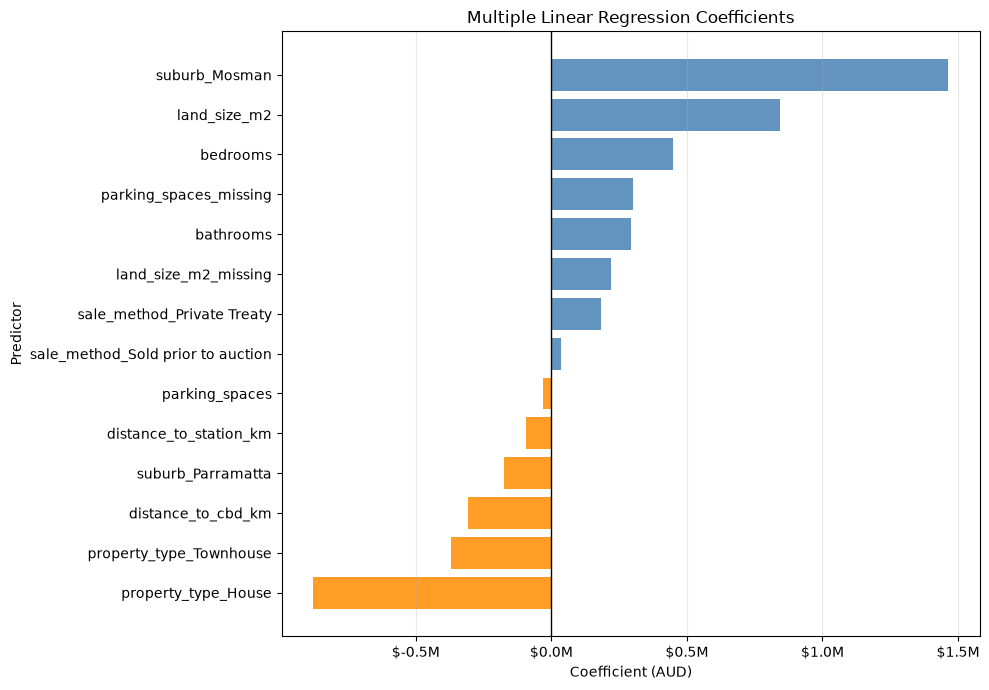

In [49]:
# ============================================================
# LINEAR REGRESSION COEFFICIENT VISUALISATION
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_df = coefficient_df.sort_values(
    "Coefficient_AUD",
    ascending=True
)                                                                   # Arrange negative to positive

colours = [
    "steelblue" if value >= 0 else "darkorange"
    for value in plot_df["Coefficient_AUD"]
]                                                                   # Blue positive; orange negative

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df["Feature"],
    plot_df["Coefficient_AUD"],
    color=colours,
    alpha=0.85
)

ax.axvline(
    0,
    color="black",
    linewidth=1
)                                                                   # Separate coefficient directions

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M")
)                                                                   # Display AUD millions

ax.set_title("Multiple Linear Regression Coefficients")
ax.set_xlabel("Coefficient (AUD)")
ax.set_ylabel("Predictor")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Observation.** Mosman had the largest positive categorical coefficient, indicating a substantially higher predicted sale price than the reference suburb, Liverpool, after holding the other predictors constant. Among the standardised numerical variables, land size and bedrooms showed the strongest positive associations with predicted price, followed by bathrooms. Distance to the CBD had a negative coefficient, indicating that greater distance was associated with a lower predicted price.

Some coefficients require cautious interpretation. House and townhouse coefficients were negative relative to the reference category, Apartment-Unit, after controlling for land size, bedrooms, bathrooms, suburb and accessibility. Similarly, Parramatta was negative relative to Liverpool after the distance variables were included. These conditional results do not mean that houses or Parramatta properties are generally cheaper. They may reflect overlap and correlation among property type, suburb, land size and distance variables. The positive missing-value coefficients indicate systematic differences among properties with unreported information rather than benefits caused by missing data.

### 3.7 Random Forest Regression

A Random Forest Regressor was developed to capture nonlinear relationships and interactions between property characteristics, location and sale price. Unlike Linear Regression, Random Forest does not assume that each predictor has a constant linear relationship with price. The initial model used standard settings before hyperparameter optimisation.

In [50]:
# ============================================================
# BASELINE RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline([
    ("numeric_imputer", PropertyTypeNumericImputer()),              # Impute land and parking
    ("preprocessor", preprocessor),                                 # Scale and encode predictors
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,                                       # Build 100 trees
            random_state=42,                                        # Reproducible results
            n_jobs=-1                                               # Use available processors
        )
    )
])

random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                   # Same five validation folds
    scoring=scoring,                                                # MAE, MSE, RMSE and R²
    n_jobs=-1                                                       # Run folds in parallel
)

random_forest_results = {
    "Model": "Random Forest",
    "MAE": -random_forest_cv["test_mae"].mean(),                    # Average fold MAE
    "MSE": -random_forest_cv["test_mse"].mean(),                    # Average fold MSE
    "RMSE": -random_forest_cv["test_rmse"].mean(),                  # Average fold RMSE
    "R2": random_forest_cv["test_r2"].mean()                        # Average fold R²
}

print("=== Random Forest: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {random_forest_results['MAE']:,.0f}")
print(f"Mean MSE  : {random_forest_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {random_forest_results['RMSE']:,.0f}")
print(f"Mean R²   : {random_forest_results['R2']:.3f}")

=== Random Forest: 5-Fold Cross-Validation ===
Mean MAE  : AUD 381,281
Mean MSE  : 383,450,904,671
Mean RMSE : AUD 608,066
Mean R²   : 0.842


**Observation.** The baseline Random Forest outperformed both the median baseline and Multiple Linear Regression. Across the five validation folds, it achieved a mean MAE of AUD 381,281, a mean RMSE of AUD 608,066 and a mean R² of 0.842. Compared with Linear Regression, Random Forest reduced MAE by approximately 35.1% and RMSE by 23.7%. This improvement suggests that sale price contains nonlinear relationships and interactions that were better captured by the ensemble of decision trees.

In [51]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

rf_parameter_grid = {
    "model__n_estimators": [100, 300, 500],                         # Number of trees
    "model__max_depth": [None, 5, 10, 15],                          # Maximum tree depth
    "model__min_samples_leaf": [1, 2, 4],                           # Minimum leaf size
    "model__max_features": ["sqrt", 1.0]                            # Features per split
}

rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_parameter_grid,
    scoring="neg_root_mean_squared_error",                          # Minimise RMSE
    cv=cv_splits,                                                   # Same five folds
    n_jobs=-1,                                                      # Run fits in parallel
    refit=True                                                      # Retain best fitted model
)

rf_grid_search.fit(X_train, y_train)                                # Tune on training data only

print("=== Optimised Random Forest ===")
print(f"Best CV RMSE : AUD {-rf_grid_search.best_score_:,.0f}")
print("\nBest parameters:")

for parameter, value in rf_grid_search.best_params_.items():
    print(f"{parameter.replace('model__', ''):<18}: {value}")

=== Optimised Random Forest ===
Best CV RMSE : AUD 568,258

Best parameters:
max_depth         : None
max_features      : sqrt
min_samples_leaf  : 1
n_estimators      : 100


In [52]:
# ============================================================
# EVALUATE OPTIMISED RANDOM FOREST
# ============================================================

best_rf_pipeline = rf_grid_search.best_estimator_                    # Best complete pipeline

optimised_rf_cv = cross_validate(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                    # Same five folds
    scoring=scoring,                                                 # Same evaluation metrics
    n_jobs=-1
)

optimised_rf_results = {
    "Model": "Optimised Random Forest",
    "MAE": -optimised_rf_cv["test_mae"].mean(),                      # Mean absolute error
    "MSE": -optimised_rf_cv["test_mse"].mean(),                      # Mean squared error
    "RMSE": -optimised_rf_cv["test_rmse"].mean(),                    # Root mean squared error
    "R2": optimised_rf_cv["test_r2"].mean()                          # Explained variation
}

print("=== Optimised Random Forest: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {optimised_rf_results['MAE']:,.0f}")
print(f"Mean MSE  : {optimised_rf_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {optimised_rf_results['RMSE']:,.0f}")
print(f"Mean R²   : {optimised_rf_results['R2']:.3f}")

=== Optimised Random Forest: 5-Fold Cross-Validation ===
Mean MAE  : AUD 363,758
Mean MSE  : 335,324,691,474
Mean RMSE : AUD 568,258
Mean R²   : 0.868


In [53]:
# ============================================================
# IMPROVEMENT FROM RANDOM FOREST TUNING
# ============================================================

rf_mae_improvement = (
    (random_forest_results["MAE"] - optimised_rf_results["MAE"])
    / random_forest_results["MAE"] * 100
)                                                                   # Percentage MAE reduction

rf_rmse_improvement = (
    (random_forest_results["RMSE"] - optimised_rf_results["RMSE"])
    / random_forest_results["RMSE"] * 100
)                                                                   # Percentage RMSE reduction

print("=== Improvement from Hyperparameter Tuning ===")
print(f"MAE reduction  : {rf_mae_improvement:.1f}%")
print(f"RMSE reduction : {rf_rmse_improvement:.1f}%")

=== Improvement from Hyperparameter Tuning ===
MAE reduction  : 4.6%
RMSE reduction : 6.5%


**Observation.** Hyperparameter tuning improved the Random Forest’s cross-validation performance. The optimised model achieved a mean MAE of AUD 363,758, a mean RMSE of AUD 568,258 and a mean R² of 0.868. Compared with the baseline Random Forest, tuning reduced MAE by approximately 4.6% and RMSE by 6.5%. The selected model used 100 trees, square-root feature sampling, unrestricted maximum depth and a minimum of one observation per leaf. These results indicate that feature sampling improved generalisation without requiring explicit depth restriction.

#### 3.7.1 Random Forest Feature Importance

Feature importance was extracted from the optimised Random Forest to examine which predictors contributed most to reducing prediction error across its decision trees. One-hot-encoded categories and missing-value indicators were aggregated back to their corresponding original predictors. This allows the results to be interpreted using the nine predictors selected before preprocessing.

In [54]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

fitted_rf_preprocessor = (
    best_rf_pipeline.named_steps["preprocessor"]
)                                                                   # Access fitted preprocessing

fitted_rf_model = (
    best_rf_pipeline.named_steps["model"]
)                                                                   # Access fitted Random Forest

rf_feature_names = (
    fitted_rf_preprocessor.get_feature_names_out()
)                                                                   # Get transformed feature names

rf_feature_names = [
    name.split("__", 1)[-1] for name in rf_feature_names
]                                                                   # Remove pipeline prefixes

rf_importance_df = pd.DataFrame({
    "Transformed_Feature": rf_feature_names,
    "Importance": fitted_rf_model.feature_importances_
})                                                                      # Importance of 14 inputs

In [55]:
# ============================================================
# AGGREGATE TO ORIGINAL PREDICTORS
# ============================================================

def map_to_original_feature(feature):

    if feature == "land_size_m2_missing":
        return "land_size_m2"                                       # Combine land indicator

    if feature == "parking_spaces_missing":
        return "parking_spaces"                                     # Combine parking indicator

    for category in categorical_features:
        if feature.startswith(f"{category}_"):
            return category                                         # Combine encoded categories

    return feature                                                  # Retain numerical name


rf_importance_df["Original_Feature"] = (
    rf_importance_df["Transformed_Feature"]
    .apply(map_to_original_feature)
)

rf_grouped_importance = (
    rf_importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)                                                                   # Produce nine importance values

rf_grouped_importance["Importance_Percent"] = (
    rf_grouped_importance["Importance"] * 100
)                                                                   # Convert to percentage

print("=== Optimised Random Forest Feature Importance ===")
print(
    rf_grouped_importance[
        ["Original_Feature", "Importance_Percent"]
    ].to_string(
        index=False,
        formatters={
            "Importance_Percent": lambda value: f"{value:.1f}%"
        }
    )
)

=== Optimised Random Forest Feature Importance ===
      Original_Feature Importance_Percent
                suburb              19.9%
distance_to_station_km              19.4%
    distance_to_cbd_km              17.4%
              bedrooms              15.4%
          land_size_m2              11.1%
             bathrooms               8.2%
         property_type               4.2%
        parking_spaces               3.4%
           sale_method               1.1%


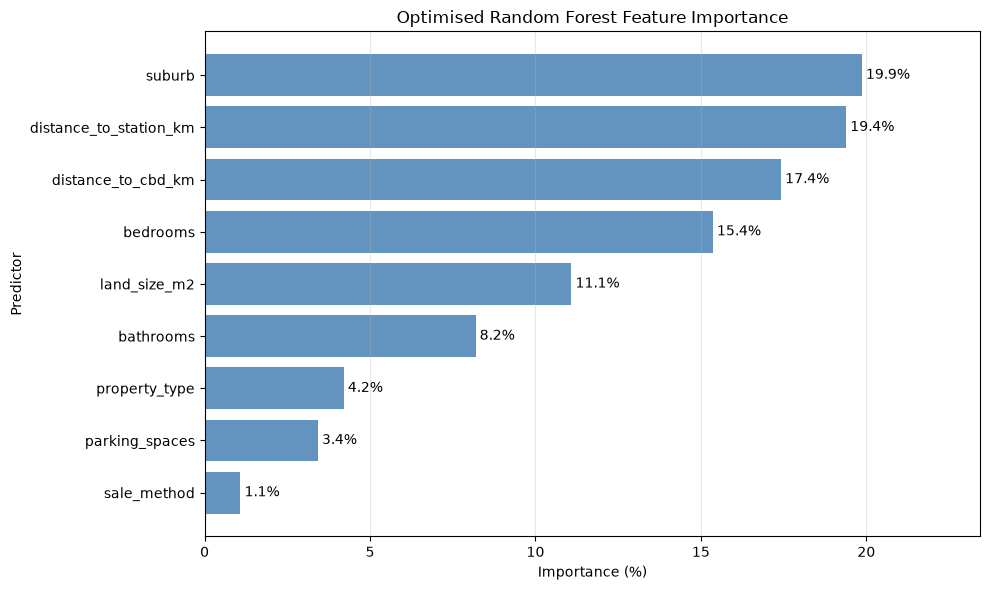

In [56]:
# ============================================================
# FEATURE-IMPORTANCE VISUALISATION
# ============================================================

import matplotlib.pyplot as plt

plot_importance = rf_grouped_importance.sort_values(
    "Importance_Percent",
    ascending=True
)                                                                   # Lowest to highest

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_importance["Original_Feature"],
    plot_importance["Importance_Percent"],
    color="steelblue",
    alpha=0.85
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_importance["Importance_Percent"]
    ],
    padding=3
)                                                                   # Display exact percentages

ax.set_title("Optimised Random Forest Feature Importance")
ax.set_xlabel("Importance (%)")
ax.set_ylabel("Predictor")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(
    0,
    plot_importance["Importance_Percent"].max() * 1.18
)                                                                   # Leave room for labels

plt.tight_layout()
plt.show()

**Observation.** Location-related predictors were the most influential in the optimised Random Forest. Suburb had the highest importance at 19.9%, followed closely by distance to the nearest station at 19.4% and distance to the CBD at 17.4%. Together, these three variables accounted for approximately 56.7% of the model’s total feature importance, indicating that broader property location and accessibility were central to its predictions.

Bedrooms and land size were the most influential property-level characteristics, contributing 15.4% and 11.1%, respectively. Bathrooms contributed 8.2%, while property type, parking spaces and sale method had smaller importance values. Sale method was the least influential predictor at 1.1%. These values show relative contribution but not whether each predictor increases or decreases predicted price. They should also be interpreted cautiously because correlated variables, particularly suburb and distance measures, may share predictive importance.

### 3.8 AdaBoost Regression

AdaBoost Regression was developed as the third predictive model and represents the boosting ensemble approach introduced in the course. The algorithm builds a sequence of weak decision-tree learners. After each stage, greater attention is given to properties with larger prediction errors, allowing subsequent learners to focus more strongly on difficult observations. The final prediction combines the contributions of the sequential learners.

#### 3.8.1 Baseline AdaBoost Model

The initial AdaBoost model used 50 shallow decision trees with a maximum depth of three. The learning rate was set to 1.0 and linear loss was used. These settings were stated explicitly before hyperparameter tuning to ensure that the baseline model was reproducible.

In [57]:
# ============================================================
# BASELINE ADABOOST REGRESSION
# ============================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

weak_learner = DecisionTreeRegressor(
    max_depth=3,                                                     # Use shallow weak learners
    random_state=42                                                  # Reproducible tree
)

adaboost_pipeline = Pipeline([
    ("numeric_imputer", PropertyTypeNumericImputer()),              # Impute land and parking
    ("preprocessor", preprocessor),                                 # Scale and encode predictors
    (
        "model",
        AdaBoostRegressor(
            estimator=weak_learner,                                  # Base decision-tree learner
            n_estimators=50,                                         # Build 50 sequential learners
            learning_rate=1.0,                                       # Contribution of each learner
            loss="linear",                                           # Linear regression loss
            random_state=42                                          # Reproducible boosting
        )
    )
])

adaboost_cv = cross_validate(
    adaboost_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                   # Same five validation folds
    scoring=scoring,                                                # MAE, MSE, RMSE and R²
    n_jobs=-1                                                       # Run folds in parallel
)

adaboost_results = {
    "Model": "AdaBoost",
    "MAE": -adaboost_cv["test_mae"].mean(),                         # Average fold MAE
    "MSE": -adaboost_cv["test_mse"].mean(),                         # Average fold MSE
    "RMSE": -adaboost_cv["test_rmse"].mean(),                       # Average fold RMSE
    "R2": adaboost_cv["test_r2"].mean()                             # Average fold R²
}

print("=== AdaBoost: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {adaboost_results['MAE']:,.0f}")
print(f"Mean MSE  : {adaboost_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {adaboost_results['RMSE']:,.0f}")
print(f"Mean R²   : {adaboost_results['R2']:.3f}")

=== AdaBoost: 5-Fold Cross-Validation ===
Mean MAE  : AUD 470,146
Mean MSE  : 429,349,025,961
Mean RMSE : AUD 652,344
Mean R²   : 0.822


**Observation.** The baseline AdaBoost model achieved a mean MAE of AUD 470,146, a mean RMSE of AUD 652,344 and a mean R² of 0.822 across the five validation folds. It performed better than Multiple Linear Regression, indicating that sequential decision-tree learners captured useful nonlinear relationships. However, it performed less strongly than the optimised Random Forest, which produced lower prediction errors and a higher R². Hyperparameter tuning was therefore conducted to determine whether AdaBoost performance could be improved.

#### 3.8.2 AdaBoost Hyperparameter Tuning

Grid search was used to to select the number of estimators, learning rate and maximum depth of the weak decision-tree learners. RMSE was used as the optimisation metric because it gives greater weight to large property-price prediction errors. The search was performed only on the training data using the same five cross-validation folds.

In [58]:
# ============================================================
# ADABOOST HYPERPARAMETER TUNING
# ============================================================

adaboost_parameter_grid = {
    "model__n_estimators": [50, 100, 200],                           # Number of weak learners
    "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],            # Learner contribution
    "model__estimator__max_depth": [1, 2, 3]                         # Weak-learner complexity
}

adaboost_grid_search = GridSearchCV(
    estimator=adaboost_pipeline,
    param_grid=adaboost_parameter_grid,
    scoring="neg_root_mean_squared_error",                          # Minimise validation RMSE
    cv=cv_splits,                                                   # Same five folds
    n_jobs=-1,                                                      # Run fits in parallel
    refit=True                                                      # Retain best fitted pipeline
)

adaboost_grid_search.fit(X_train, y_train)                           # Tune on training data only

print("=== Optimised AdaBoost ===")
print(f"Best CV RMSE : AUD {-adaboost_grid_search.best_score_:,.0f}")
print("\nBest parameters:")

for parameter, value in adaboost_grid_search.best_params_.items():
    print(f"{parameter.replace('model__', ''):<22}: {value}")

=== Optimised AdaBoost ===
Best CV RMSE : AUD 638,637

Best parameters:
estimator__max_depth  : 3
learning_rate         : 0.1
n_estimators          : 100


In [59]:
# ============================================================
# EVALUATE OPTIMISED ADABOOST
# ============================================================

best_adaboost_pipeline = (
    adaboost_grid_search.best_estimator_
)                                                                   # Best complete pipeline

optimised_adaboost_cv = cross_validate(
    best_adaboost_pipeline,
    X_train,
    y_train,
    cv=cv_splits,                                                   # Same five validation folds
    scoring=scoring,                                                # Same evaluation metrics
    n_jobs=-1                                                       # Run folds in parallel
)

optimised_adaboost_results = {
    "Model": "Optimised AdaBoost",
    "MAE": -optimised_adaboost_cv["test_mae"].mean(),               # Average fold MAE
    "MSE": -optimised_adaboost_cv["test_mse"].mean(),               # Average fold MSE
    "RMSE": -optimised_adaboost_cv["test_rmse"].mean(),             # Average fold RMSE
    "R2": optimised_adaboost_cv["test_r2"].mean()                   # Average fold R²
}

print("=== Optimised AdaBoost: 5-Fold Cross-Validation ===")
print(f"Mean MAE  : AUD {optimised_adaboost_results['MAE']:,.0f}")
print(f"Mean MSE  : {optimised_adaboost_results['MSE']:,.0f}")
print(f"Mean RMSE : AUD {optimised_adaboost_results['RMSE']:,.0f}")
print(f"Mean R²   : {optimised_adaboost_results['R2']:.3f}")

=== Optimised AdaBoost: 5-Fold Cross-Validation ===
Mean MAE  : AUD 412,914
Mean MSE  : 414,971,888,868
Mean RMSE : AUD 638,637
Mean R²   : 0.833


In [60]:
# ============================================================
# IMPROVEMENT FROM ADABOOST TUNING
# ============================================================

adaboost_mae_improvement = (
    (adaboost_results["MAE"] - optimised_adaboost_results["MAE"])
    / adaboost_results["MAE"] * 100
)                                                                   # Percentage MAE reduction

adaboost_rmse_improvement = (
    (adaboost_results["RMSE"] - optimised_adaboost_results["RMSE"])
    / adaboost_results["RMSE"] * 100
)                                                                   # Percentage RMSE reduction

print("=== Improvement from AdaBoost Tuning ===")
print(f"MAE reduction  : {adaboost_mae_improvement:.1f}%")
print(f"RMSE reduction : {adaboost_rmse_improvement:.1f}%")

=== Improvement from AdaBoost Tuning ===
MAE reduction  : 12.2%
RMSE reduction : 2.1%


**Observation.** Hyperparameter tuning improved AdaBoost performance. The optimised model used 100 sequential trees, a learning rate of 0.1 and a maximum weak-learner depth of three. It achieved a mean MAE of AUD 412,914, a mean RMSE of AUD 638,637 and a mean R² of 0.833. Compared with the baseline AdaBoost model, tuning reduced MAE by 12.2% and RMSE by 2.1%. The larger improvement in MAE indicates that tuning reduced typical prediction errors more substantially than the largest errors, which receive greater emphasis from RMSE. Although performance improved, the optimised Random Forest remained stronger, with lower MAE and RMSE and a higher R².

#### 3.8.3 AdaBoost Feature Importance

Feature importance was extracted from the optimised AdaBoost model to identify which predictors contributed most strongly to its sequential decision-tree predictions. The transformed categorical columns and missing-value indicators were aggregated back to the nine original predictors to support direct interpretation.

In [61]:
# ============================================================
# ADABOOST FEATURE IMPORTANCE
# ============================================================

fitted_adaboost_preprocessor = (
    best_adaboost_pipeline.named_steps["preprocessor"]
)                                                                   # Access fitted preprocessing

fitted_adaboost_model = (
    best_adaboost_pipeline.named_steps["model"]
)                                                                   # Access fitted AdaBoost model

adaboost_feature_names = (
    fitted_adaboost_preprocessor.get_feature_names_out()
)                                                                   # Get transformed feature names

adaboost_feature_names = [
    name.split("__", 1)[-1] for name in adaboost_feature_names
]                                                                   # Remove pipeline prefixes

adaboost_importance_df = pd.DataFrame({
    "Transformed_Feature": adaboost_feature_names,
    "Importance": fitted_adaboost_model.feature_importances_
})                                                                  # Importance of transformed inputs

In [62]:
# ============================================================
# AGGREGATE TO ORIGINAL PREDICTORS
# ============================================================

adaboost_importance_df["Original_Feature"] = (
    adaboost_importance_df["Transformed_Feature"]
    .apply(map_to_original_feature)
)                                                                   # Map to nine predictors

adaboost_grouped_importance = (
    adaboost_importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)                                                                   # Sum related transformed inputs

adaboost_grouped_importance["Importance_Percent"] = (
    adaboost_grouped_importance["Importance"] * 100
)                                                                   # Convert to percentage

print("=== Optimised AdaBoost Feature Importance ===")
print(
    adaboost_grouped_importance[
        ["Original_Feature", "Importance_Percent"]
    ].to_string(
        index=False,
        formatters={
            "Importance_Percent": lambda value: f"{value:.1f}%"
        }
    )
)

=== Optimised AdaBoost Feature Importance ===
      Original_Feature Importance_Percent
              bedrooms              32.1%
    distance_to_cbd_km              20.8%
distance_to_station_km              16.7%
          land_size_m2              13.7%
                suburb               8.9%
             bathrooms               5.9%
        parking_spaces               1.6%
         property_type               0.2%
           sale_method               0.1%


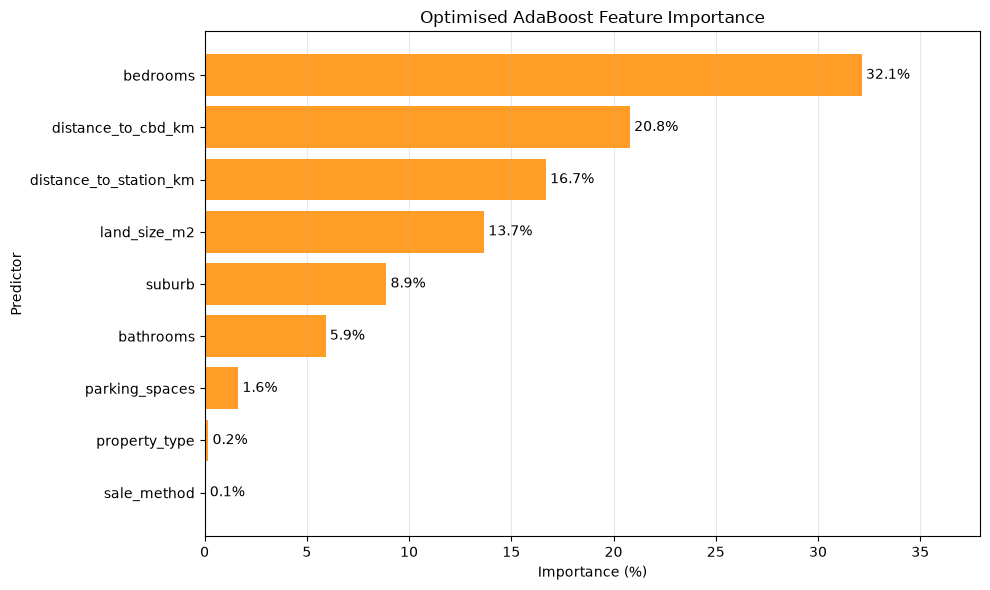

In [63]:
# ============================================================
# ADABOOST FEATURE-IMPORTANCE VISUALISATION
# ============================================================

plot_adaboost_importance = adaboost_grouped_importance.sort_values(
    "Importance_Percent",
    ascending=True
)                                                                   # Lowest to highest

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_adaboost_importance["Original_Feature"],
    plot_adaboost_importance["Importance_Percent"],
    color="darkorange",
    alpha=0.85
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_adaboost_importance["Importance_Percent"]
    ],
    padding=3
)                                                                   # Display exact percentages

ax.set_title("Optimised AdaBoost Feature Importance")
ax.set_xlabel("Importance (%)")
ax.set_ylabel("Predictor")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(
    0,
    plot_adaboost_importance["Importance_Percent"].max() * 1.18
)                                                                   # Leave room for labels

plt.tight_layout()
plt.show()

**Observation.** Bedrooms was the most influential predictor in the optimised AdaBoost model, accounting for 32.1% of total importance. Distance to the CBD contributed 20.8%, followed by distance to the nearest station at 16.7% and land size at 13.7%. Suburb and bathrooms made smaller contributions of 8.9% and 5.9%, respectively, while parking spaces, property type and sale method contributed very little.

Compared with Random Forest, AdaBoost concentrated substantially more importance on bedrooms, while Random Forest distributed importance more evenly across suburb, transport accessibility, CBD distance and property characteristics. This difference reflects how the algorithms learn: AdaBoost sequentially emphasises predictors that help correct previous errors, whereas Random Forest averages results across independently constructed trees. The importance values indicate relative predictive contribution, not causal effects or the direction of each relationship.

### 3.9 Cross-Validation Model Comparison

The models were compared using the mean results from the same five cross-validation folds. MAE represents the typical absolute prediction error, while RMSE gives greater emphasis to large errors. R² measures the proportion of sale-price variation explained by each model. The optimised versions of Random Forest and AdaBoost were compared with their baseline configurations to assess the effect of hyperparameter tuning.

In [64]:
# ============================================================
# CROSS-VALIDATION MODEL COMPARISON
# ============================================================

comparison_results = pd.DataFrame([
    baseline_results,
    linear_results,
    random_forest_results,
    optimised_rf_results,
    adaboost_results,
    optimised_adaboost_results
])                                                                  # Combine all model results

comparison_results = comparison_results[
    ["Model", "MAE", "MSE", "RMSE", "R2"]
]                                                                   # Set consistent column order

comparison_display = comparison_results[
    ["Model", "MAE", "RMSE", "R2"]
].copy()                                                            # Keep interpretable metrics

comparison_display["MAE"] = comparison_display["MAE"].map(
    lambda value: f"AUD {value:,.0f}"
)                                                                   # Format MAE as currency

comparison_display["RMSE"] = comparison_display["RMSE"].map(
    lambda value: f"AUD {value:,.0f}"
)                                                                   # Format RMSE as currency

comparison_display["R2"] = comparison_display["R2"].map(
    lambda value: f"{value:.3f}"
)                                                                   # Format R² consistently

print("=== Five-Fold Cross-Validation Model Comparison ===")
print(comparison_display.to_string(index=False))

=== Five-Fold Cross-Validation Model Comparison ===
                  Model           MAE          RMSE     R2
        Median Baseline AUD 1,101,769 AUD 1,716,905 -0.122
      Linear Regression   AUD 587,433   AUD 797,248  0.724
          Random Forest   AUD 381,281   AUD 608,066  0.842
Optimised Random Forest   AUD 363,758   AUD 568,258  0.868
               AdaBoost   AUD 470,146   AUD 652,344  0.822
     Optimised AdaBoost   AUD 412,914   AUD 638,637  0.833


In [65]:
# ============================================================
# SELECT BEST MAIN MODEL
# ============================================================

main_models = [
    "Linear Regression",
    "Optimised Random Forest",
    "Optimised AdaBoost"
]                                                                   # Three final model candidates

main_model_results = comparison_results[
    comparison_results["Model"].isin(main_models)
].copy()                                                            # Exclude intermediate baselines

best_model_row = main_model_results.loc[
    main_model_results["RMSE"].idxmin()
]                                                                   # Select lowest mean RMSE

print("=== Best Cross-Validation Model ===")
print(f"Model : {best_model_row['Model']}")
print(f"MAE   : AUD {best_model_row['MAE']:,.0f}")
print(f"RMSE  : AUD {best_model_row['RMSE']:,.0f}")
print(f"R²    : {best_model_row['R2']:.3f}")

=== Best Cross-Validation Model ===
Model : Optimised Random Forest
MAE   : AUD 363,758
RMSE  : AUD 568,258
R²    : 0.868


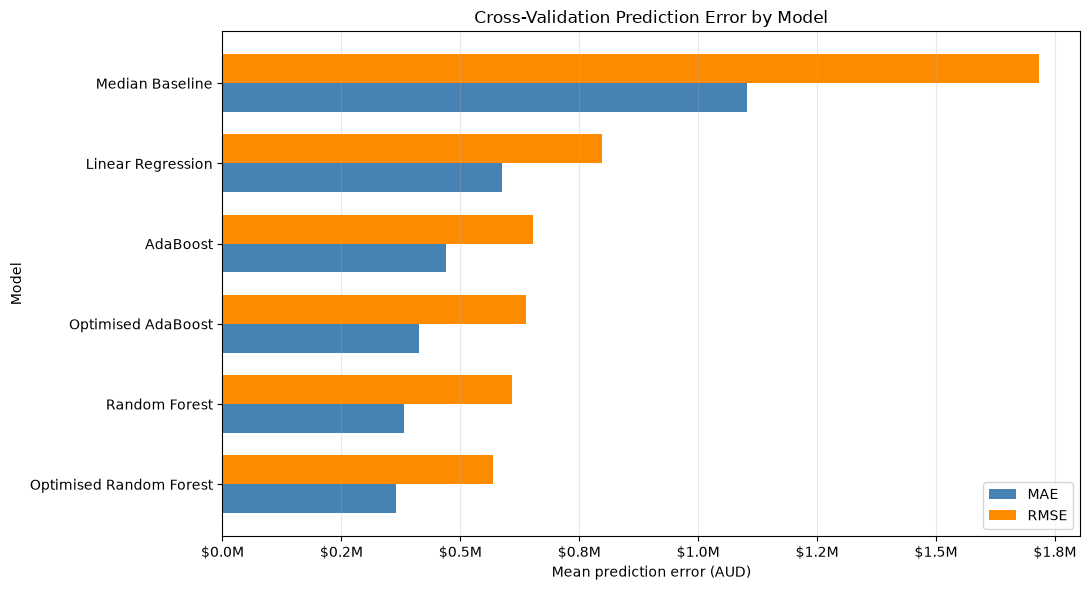

In [66]:
# ============================================================
# MODEL ERROR COMPARISON
# ============================================================

from matplotlib.ticker import FuncFormatter

plot_comparison = comparison_results.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)                                            # Rank models by RMSE

positions = np.arange(len(plot_comparison))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    positions - bar_height / 2,
    plot_comparison["MAE"],
    height=bar_height,
    label="MAE",
    color="steelblue"
)

ax.barh(
    positions + bar_height / 2,
    plot_comparison["RMSE"],
    height=bar_height,
    label="RMSE",
    color="darkorange"
)

ax.set_yticks(positions)
ax.set_yticklabels(plot_comparison["Model"])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M")
)                                                                   # Display AUD millions

ax.set_title("Cross-Validation Prediction Error by Model")
ax.set_xlabel("Mean prediction error (AUD)")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Observation.** All three trained regression approaches outperformed the median baseline. Multiple Linear Regression reduced prediction error substantially and explained 72.4% of the validation-fold price variation, but both ensemble approaches performed better. Hyperparameter tuning improved Random Forest and AdaBoost, although Random Forest achieved the strongest overall results. The optimised Random Forest produced the lowest mean MAE of AUD 363,758, the lowest mean RMSE of AUD 568,258 and the highest mean R² of 0.868. It was therefore selected for final evaluation on the reserved test set. The test data had not been used during preprocessing, model fitting, cross-validation or hyperparameter selection.

#### 3.9.1 Model Complexity and Generalisation

Training and validation performance were compared to assess possible underfitting or overfitting. A model with high errors on both subsets may be underfitting, while substantially lower training error than validation error may indicate overfitting. The size of this performance gap was considered together with each model’s overall validation accuracy.

In [67]:
# ============================================================
# TRAINING AND VALIDATION PERFORMANCE
# ============================================================

complexity_models = {
    "Linear Regression": linear_pipeline,
    "Optimised Random Forest": best_rf_pipeline,
    "Optimised AdaBoost": best_adaboost_pipeline
}                                                                   # Three final model candidates

complexity_results = []

for model_name, model_pipeline in complexity_models.items():

    model_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_splits,                                               # Same five validation folds
        scoring=scoring,                                            # Same evaluation metrics
        return_train_score=True,                                    # Include training performance
        n_jobs=-1
    )

    train_mae = -model_scores["train_mae"].mean()
    validation_mae = -model_scores["test_mae"].mean()

    train_rmse = -model_scores["train_rmse"].mean()
    validation_rmse = -model_scores["test_rmse"].mean()

    train_r2 = model_scores["train_r2"].mean()
    validation_r2 = model_scores["test_r2"].mean()

    complexity_results.append({
        "Model": model_name,
        "Train_MAE": train_mae,
        "Validation_MAE": validation_mae,
        "Train_RMSE": train_rmse,
        "Validation_RMSE": validation_rmse,
        "Train_R2": train_r2,
        "Validation_R2": validation_r2,
        "RMSE_Gap": validation_rmse - train_rmse
    })                                                              # Store fold averages

complexity_results = pd.DataFrame(complexity_results)

In [68]:
# ============================================================
# DISPLAY COMPLEXITY RESULTS
# ============================================================

complexity_display = complexity_results.copy()

currency_columns = [
    "Train_MAE",
    "Validation_MAE",
    "Train_RMSE",
    "Validation_RMSE",
    "RMSE_Gap"
]

for column in currency_columns:
    complexity_display[column] = complexity_display[column].map(
        lambda value: f"AUD {value:,.0f}"
    )                                                               # Format errors as currency

complexity_display["Train_R2"] = complexity_display["Train_R2"].map(
    lambda value: f"{value:.3f}"
)

complexity_display["Validation_R2"] = (
    complexity_display["Validation_R2"].map(
        lambda value: f"{value:.3f}"
    )
)

print("=== Training versus Validation Performance ===")
print(complexity_display.to_string(index=False))

=== Training versus Validation Performance ===
                  Model   Train_MAE Validation_MAE  Train_RMSE Validation_RMSE Train_R2 Validation_R2    RMSE_Gap
      Linear Regression AUD 498,599    AUD 587,433 AUD 677,423     AUD 797,248    0.831         0.724 AUD 119,825
Optimised Random Forest AUD 142,219    AUD 363,758 AUD 234,117     AUD 568,258    0.980         0.868 AUD 334,141
     Optimised AdaBoost AUD 216,201    AUD 412,914 AUD 289,219     AUD 638,637    0.969         0.833 AUD 349,418


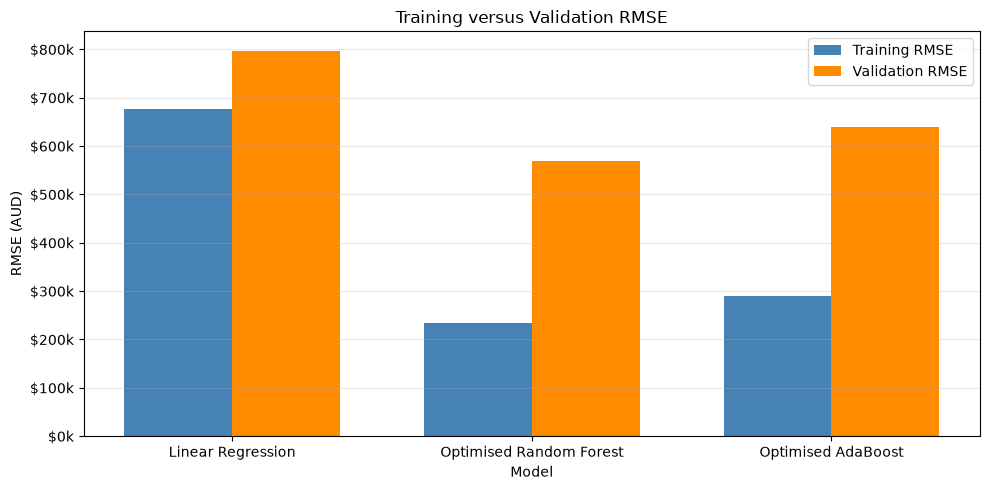

In [69]:
# ============================================================
# TRAINING VERSUS VALIDATION RMSE
# ============================================================

positions = np.arange(len(complexity_results))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    positions - bar_width / 2,
    complexity_results["Train_RMSE"],
    width=bar_width,
    label="Training RMSE",
    color="steelblue"
)

ax.bar(
    positions + bar_width / 2,
    complexity_results["Validation_RMSE"],
    width=bar_width,
    label="Validation RMSE",
    color="darkorange"
)

ax.set_xticks(positions)
ax.set_xticklabels(complexity_results["Model"])
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000:.0f}k")
)                                                                   # Display AUD thousands

ax.set_title("Training versus Validation RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (AUD)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Observation.** Multiple Linear Regression showed the smallest difference between training and validation RMSE, but both errors were comparatively high. This indicates that the model generalised consistently but was limited by its simple linear structure, suggesting some underfitting of the nonlinear property-price relationships.

The optimised Random Forest achieved a much lower training RMSE and the lowest validation RMSE, although the larger gap between them indicates some overfitting. Despite this gap, it retained the strongest validation and final test performance, showing that its additional complexity captured useful patterns that Linear Regression missed.

Optimised AdaBoost also achieved substantially lower training error than validation error, indicating overfitting. However, its validation RMSE remained higher than that of Random Forest. This suggests that AdaBoost’s sequential focus on difficult observations increased model complexity without producing the same generalisation benefit. Overall, Random Forest provided the best balance between predictive accuracy and generalisation, while its remaining overfitting risk should be recognised.

#### 3.9.2 Reassessment of Initial Expectations

Before training, Random Forest was expected to perform best because property prices were likely to depend on nonlinear relationships and interactions among suburb, property type, size and accessibility. This expectation was supported by the experimental results. The optimised Random Forest achieved the lowest cross-validation MAE and RMSE and the highest R² of the three models. Its stronger performance indicates that a nonlinear ensemble was better suited to the structure of the dataset than a purely linear model.

AdaBoost was expected to provide competitive performance but to be potentially sensitive to unusual property sales. This expectation was partly supported. AdaBoost outperformed Linear Regression, showing that boosting captured useful nonlinear patterns, but it remained weaker than Random Forest and showed a substantial training-validation performance gap. The large residuals associated with several unusual properties also support the concern that sequentially focusing on difficult observations may not have provided the most stable generalisation.

The feature results also partly supported the expectations established during data exploration. Location was highly influential in Random Forest, with suburb, distance to the nearest station and distance to the CBD collectively accounting for 56.7% of total importance. Bedrooms and land size were also important, supporting the expectation that property size and capacity would influence price. However, property type had relatively low independent importance, possibly because much of its information was already represented by bedrooms, bathrooms and land size. Station distance was predictively important, but its relationship with price was not uniformly in the expected direction because it was strongly influenced by differences among the three suburb markets.

Overall, the experiments supported the expectation that Random Forest would be the most appropriate model. Linear Regression provided useful interpretation but showed some underfitting, while AdaBoost introduced additional nonlinear flexibility without matching the generalisation performance of Random Forest.

### 3.10 Final Test-Set Evaluation

The optimised Random Forest was evaluated once on the reserved 20% test set. These 24 properties were not used during model training, preprocessing or hyperparameter selection. The test results therefore provide an estimate of performance on previously unseen properties.

In [70]:
# ============================================================
# FINAL TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

final_model = best_rf_pipeline                                      # Select optimised Random Forest
final_model.fit(X_train, y_train)                                   # Fit on all training observations

y_test_pred = final_model.predict(X_test)                           # Predict reserved test prices

test_mae = mean_absolute_error(y_test, y_test_pred)                 # Test absolute error
test_mse = mean_squared_error(y_test, y_test_pred)                  # Test squared error
test_rmse = np.sqrt(test_mse)                                       # Convert MSE to AUD
test_r2 = r2_score(y_test, y_test_pred)                             # Test explained variation

print("=== Optimised Random Forest: Final Test Results ===")
print(f"Test observations : {len(y_test)}")
print(f"Test MAE          : AUD {test_mae:,.0f}")
print(f"Test MSE          : {test_mse:,.0f}")
print(f"Test RMSE         : AUD {test_rmse:,.0f}")
print(f"Test R²           : {test_r2:.3f}")

=== Optimised Random Forest: Final Test Results ===
Test observations : 24
Test MAE          : AUD 404,830
Test MSE          : 350,274,284,508
Test RMSE         : AUD 591,840
Test R²           : 0.656


In [71]:
# ============================================================
# TEST PREDICTION RESULTS
# ============================================================

test_predictions = df_model.loc[
    X_test.index,
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms"
    ]
].copy()                                                            # Retain property context

test_predictions["Actual_Price"] = y_test                           # Add observed price
test_predictions["Predicted_Price"] = y_test_pred                   # Add model prediction

test_predictions["Error"] = (
    test_predictions["Predicted_Price"]
    - test_predictions["Actual_Price"]
)                                                                   # Positive means overprediction

test_predictions["Absolute_Error"] = (
    test_predictions["Error"].abs()
)                                                                   # Measure error magnitude

test_predictions = test_predictions.sort_values(
    "Absolute_Error",
    ascending=False
)                                                                   # Largest errors first

print("=== Test Predictions: Largest Errors First ===")
print(
    test_predictions.to_string(
        index=False,
        formatters={
            "Actual_Price": lambda value: f"AUD {value:,.0f}",
            "Predicted_Price": lambda value: f"AUD {value:,.0f}",
            "Error": lambda value: f"AUD {value:,.0f}",
            "Absolute_Error": lambda value: f"AUD {value:,.0f}"
        }
    )
)

=== Test Predictions: Largest Errors First ===
                 address     suburb  property_type  bedrooms  bathrooms  Actual_Price Predicted_Price         Error Absolute_Error
    24/27 Warringah Road     Mosman Apartment-Unit         1          1   AUD 788,000   AUD 2,561,980 AUD 1,773,980  AUD 1,773,980
      4/15 Roland Avenue  Liverpool      Townhouse         4          3   AUD 980,000   AUD 2,126,927 AUD 1,146,927  AUD 1,146,927
          32 Lang Street     Mosman          House         5          2 AUD 3,900,000   AUD 4,815,440   AUD 915,440    AUD 915,440
     2/81A Glover Street     Mosman Apartment-Unit         2          2 AUD 1,440,000   AUD 2,295,430   AUD 855,430    AUD 855,430
     271 Memorial Avenue  Liverpool          House         3          1 AUD 1,505,000   AUD 2,262,880   AUD 757,880    AUD 757,880
      11/1A Queen Street     Mosman Apartment-Unit         2          1 AUD 1,325,000   AUD 2,028,785   AUD 703,785    AUD 703,785
      38 Inkerman Street Parramatta 

#### 3.10.1 Actual versus Predicted Prices

**Observation.** All five largest errors were overpredictions. The cases suggest that the Random Forest relied strongly on suburb, room counts and land size but could not account for omitted contextual factors such as internal floor area, property condition, strata arrangements and planning constraints. The model therefore struggled with properties whose basic characteristics appeared valuable but whose actual market value was reduced by information unavailable in the training data.

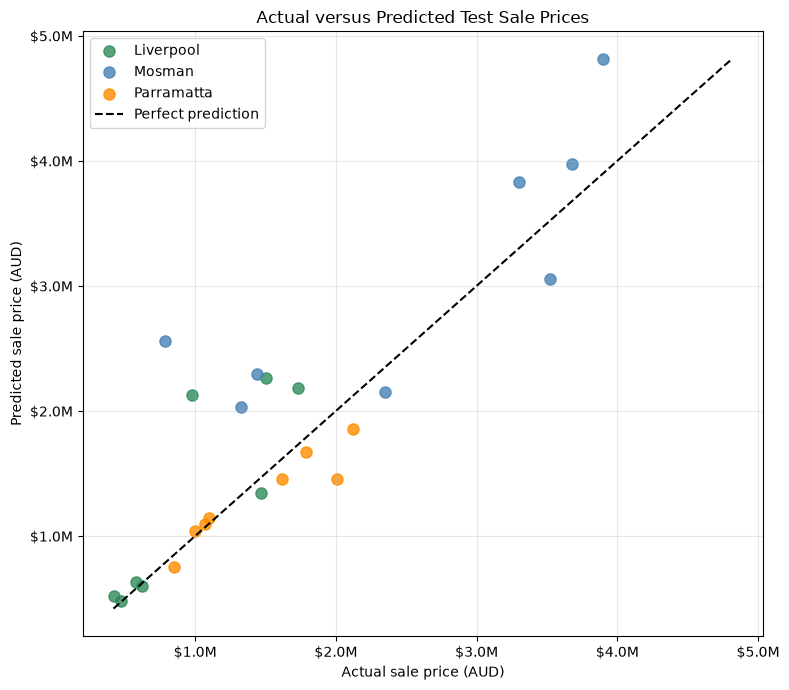

In [72]:
# ============================================================
# ACTUAL VERSUS PREDICTED TEST PRICES
# ============================================================

from matplotlib.ticker import FuncFormatter

prediction_plot = X_test[["suburb"]].copy()                         # Retain suburb groups
prediction_plot["Actual"] = y_test                                  # Observed sale prices
prediction_plot["Predicted"] = y_test_pred                          # Model predictions

suburb_colours = {
    "Mosman": "steelblue",
    "Parramatta": "darkorange",
    "Liverpool": "seagreen"
}

fig, ax = plt.subplots(figsize=(8, 7))

for suburb, group in prediction_plot.groupby("suburb"):
    ax.scatter(
        group["Actual"],
        group["Predicted"],
        label=suburb,
        color=suburb_colours[suburb],
        s=65,
        alpha=0.8
    )                                                               # Plot each suburb separately

minimum_price = min(
    prediction_plot["Actual"].min(),
    prediction_plot["Predicted"].min()
)

maximum_price = max(
    prediction_plot["Actual"].max(),
    prediction_plot["Predicted"].max()
)

ax.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction"
)                                                                   # Add ideal prediction line

currency_formatter = FuncFormatter(
    lambda value, _: f"${value / 1_000_000:.1f}M"
)

ax.xaxis.set_major_formatter(currency_formatter)
ax.yaxis.set_major_formatter(currency_formatter)

ax.set_title("Actual versus Predicted Test Sale Prices")
ax.set_xlabel("Actual sale price (AUD)")
ax.set_ylabel("Predicted sale price (AUD)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Observation.** Most test predictions followed the general upward relationship between actual and predicted sale prices, although prediction accuracy varied across property markets. Liverpool properties were generally concentrated at the lower end of the price range and several predictions were close to the perfect-prediction line. Parramatta properties showed moderate errors, with some higher-priced properties being underpredicted.

The largest errors were concentrated among Mosman properties. Several lower-priced Mosman apartments were substantially overpredicted, including 24/27 Warringah Road, which sold for AUD 788,000 but was predicted at approximately AUD 2.56 million. Some higher-value Mosman properties were also underpredicted. This suggests that the model learned Mosman’s generally high price level but had difficulty representing unusually low-priced apartments and variation within that suburb. These errors help explain why test RMSE was considerably higher than MAE.

#### 3.10.2 Test Performance by Suburb

Test performance was examined separately for each suburb to determine whether prediction accuracy was consistent across the three property markets. Each suburb contributed eight observations to the test set. MAE and RMSE were calculated within each group, while R² was included cautiously because it can be unstable when calculated from only eight observations.

In [73]:
# ============================================================
# TEST PERFORMANCE BY SUBURB
# ============================================================

suburb_test_results = []

for suburb, group in prediction_plot.groupby("suburb"):

    suburb_mae = mean_absolute_error(
        group["Actual"],
        group["Predicted"]
    )                                                               # Suburb mean absolute error

    suburb_mse = mean_squared_error(
        group["Actual"],
        group["Predicted"]
    )                                                               # Suburb mean squared error

    suburb_rmse = np.sqrt(suburb_mse)                                # Convert MSE to AUD

    suburb_r2 = r2_score(
        group["Actual"],
        group["Predicted"]
    )                                                               # Suburb explained variation

    suburb_test_results.append({
        "Suburb": suburb,
        "Properties": len(group),
        "MAE": suburb_mae,
        "RMSE": suburb_rmse,
        "R2": suburb_r2
    })

suburb_test_results = pd.DataFrame(
    suburb_test_results
).sort_values("RMSE")                                                # Rank by prediction error

suburb_display = suburb_test_results.copy()

suburb_display["MAE"] = suburb_display["MAE"].map(
    lambda value: f"AUD {value:,.0f}"
)                                                                   # Format MAE

suburb_display["RMSE"] = suburb_display["RMSE"].map(
    lambda value: f"AUD {value:,.0f}"
)                                                                   # Format RMSE

suburb_display["R2"] = suburb_display["R2"].map(
    lambda value: f"{value:.3f}"
)                                                                   # Format R²

print("=== Final Test Performance by Suburb ===")
print(suburb_display.to_string(index=False))

=== Final Test Performance by Suburb ===
    Suburb  Properties         MAE        RMSE     R2
Parramatta           8 AUD 163,134 AUD 233,213  0.750
 Liverpool           8 AUD 332,767 AUD 515,450 -0.099
    Mosman           8 AUD 718,589 AUD 854,837  0.442


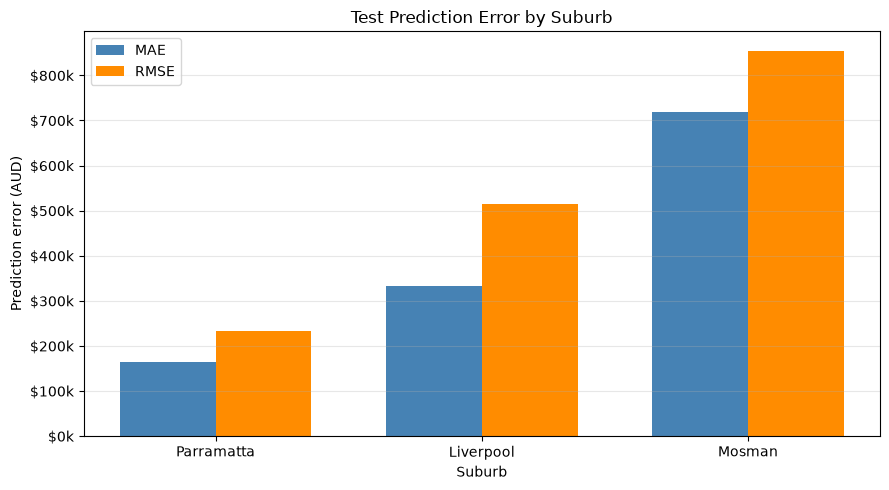

In [74]:
# ============================================================
# SUBURB ERROR COMPARISON
# ============================================================

positions = np.arange(len(suburb_test_results))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    positions - bar_width / 2,
    suburb_test_results["MAE"],
    width=bar_width,
    label="MAE",
    color="steelblue"
)

ax.bar(
    positions + bar_width / 2,
    suburb_test_results["RMSE"],
    width=bar_width,
    label="RMSE",
    color="darkorange"
)

ax.set_xticks(positions)
ax.set_xticklabels(suburb_test_results["Suburb"])
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000:.0f}k")
)                                                                   # Display AUD thousands

ax.set_title("Test Prediction Error by Suburb")
ax.set_xlabel("Suburb")
ax.set_ylabel("Prediction error (AUD)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Observation.** Test prediction error varied considerably across the three suburbs. Parramatta produced the lowest MAE and RMSE, indicating the most consistent predictions. Liverpool showed intermediate error, while Mosman produced substantially higher MAE and RMSE than the other suburbs. This confirms that a large proportion of the overall test error was driven by Mosman properties.

The weaker Mosman performance is consistent with its wider price range and the presence of several lower-priced apartments alongside high-value houses and townhouses. With only eight test properties per suburb, individual unusual sales can strongly affect these subgroup results. The model should therefore be used more cautiously for Mosman properties, particularly those that differ from the typical properties represented in the training data.

## 3.11 Residual Analysis

Residuals were examined to identify systematic overprediction or underprediction in the optimised Random Forest. A residual was calculated as the actual sale price minus the predicted price. Positive residuals therefore indicate underprediction, while negative residuals indicate overprediction. For a well-performing model, residuals should generally be distributed around zero without a strong pattern across predicted prices.

In [75]:
# ============================================================
# TEST RESIDUAL SUMMARY
# ============================================================

test_residuals = (
    y_test.to_numpy() - y_test_pred
)                                                                   # Actual minus predicted price

mean_residual = test_residuals.mean()                                # Overall prediction bias
median_residual = np.median(test_residuals)                          # Typical residual
overpredictions = (test_residuals < 0).sum()                         # Predicted above actual
underpredictions = (test_residuals > 0).sum()                        # Predicted below actual

print("=== Test Residual Summary ===")
print(f"Mean residual       : AUD {mean_residual:,.0f}")
print(f"Median residual     : AUD {median_residual:,.0f}")
print(f"Overpredictions     : {overpredictions}")
print(f"Underpredictions    : {underpredictions}")
print(f"Exact predictions   : {(test_residuals == 0).sum()}")

=== Test Residual Summary ===
Mean residual       : AUD -237,288
Median residual     : AUD -39,754
Overpredictions     : 15
Underpredictions    : 9
Exact predictions   : 0


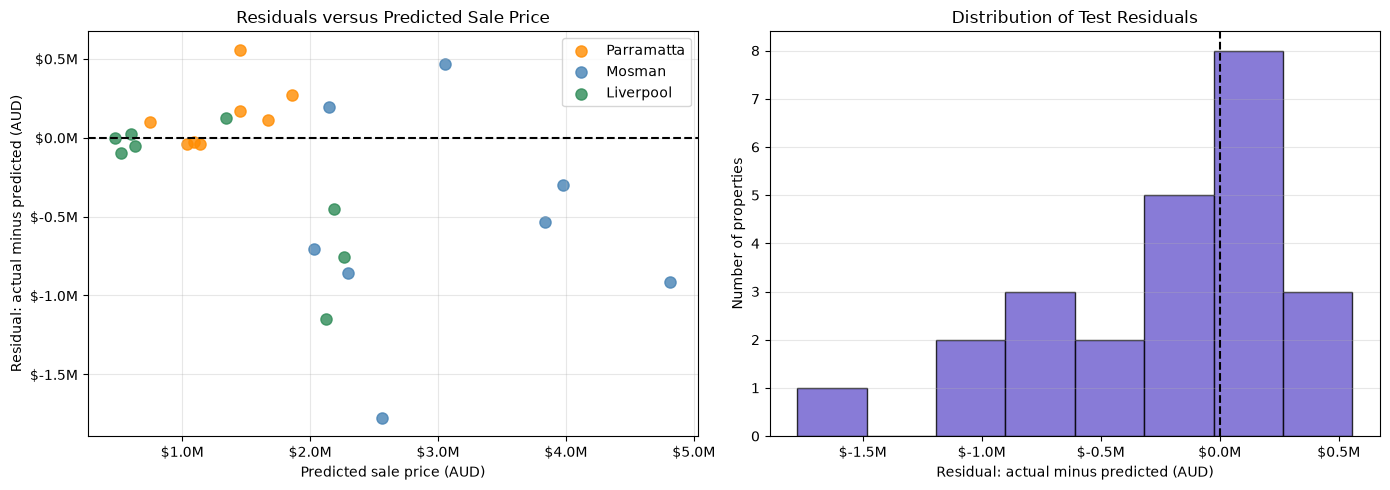

In [76]:
# ============================================================
# RESIDUAL VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for suburb in prediction_plot["suburb"].unique():
    suburb_mask = prediction_plot["suburb"] == suburb

    axes[0].scatter(
        y_test_pred[suburb_mask],
        test_residuals[suburb_mask],
        label=suburb,
        color=suburb_colours[suburb],
        s=65,
        alpha=0.8
    )                                                               # Residuals by suburb

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)                                                                   # Perfect-prediction line

axes[0].xaxis.set_major_formatter(currency_formatter)
axes[0].yaxis.set_major_formatter(currency_formatter)
axes[0].set_title("Residuals versus Predicted Sale Price")
axes[0].set_xlabel("Predicted sale price (AUD)")
axes[0].set_ylabel("Residual: actual minus predicted (AUD)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(
    test_residuals,
    bins=8,
    color="slateblue",
    edgecolor="black",
    alpha=0.8
)                                                                   # Show residual distribution

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)                                                                   # Separate error directions

axes[1].xaxis.set_major_formatter(currency_formatter)
axes[1].set_title("Distribution of Test Residuals")
axes[1].set_xlabel("Residual: actual minus predicted (AUD)")
axes[1].set_ylabel("Number of properties")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Observation.** Many test residuals were concentrated reasonably close to zero, particularly among lower-priced Liverpool and Parramatta properties. However, the residual distribution was negatively skewed because several properties were substantially overpredicted. The largest negative residuals were mainly associated with Mosman properties and one Liverpool property, consistent with the large errors identified in the prediction table.

Residual dispersion also increased at higher predicted prices, indicating that prediction uncertainty was greater for more expensive properties. The results do not show a completely random and balanced distribution around zero. Instead, they suggest that the model tends to overpredict some unusual lower-priced properties located within generally higher-value market segments. This limitation should be communicated when the model is deployed.

## 3.12 Reassessment of Initial Expectations

Before training, Random Forest was expected to perform best because property prices were likely to depend on nonlinear relationships and interactions among suburb, property type, size and accessibility. This expectation was supported by the experimental results. The optimised Random Forest achieved the lowest cross-validation MAE and RMSE and the highest R² of the three models, indicating that a nonlinear bagging ensemble was well suited to the dataset.

AdaBoost was expected to provide competitive performance but to be potentially sensitive to unusual property sales. This expectation was partly supported. AdaBoost outperformed Multiple Linear Regression but remained weaker than Random Forest and showed a substantial difference between training and validation error. This suggests that its sequential focus on difficult observations increased model complexity without providing the same generalisation benefit as Random Forest.

Multiple Linear Regression was expected to provide useful interpretation but lower predictive accuracy if the relationships were not entirely linear. This expectation was supported. It substantially outperformed the median baseline but produced higher validation errors than both ensemble models. Its comparatively high training and validation errors also indicated that its linear structure underfit some of the relationships in the data.

The feature results partly supported the expectations established during data exploration. Location was highly influential in Random Forest, with suburb, distance to the nearest station and distance to the CBD collectively accounting for 56.7% of total importance. Bedrooms and land size were also important, supporting the expectation that property size and capacity would influence price. However, property type had relatively low independent importance, possibly because its information overlapped with bedrooms, bathrooms and land size. Station distance was predictively important, but its relationship with price was not uniformly in the expected direction because it was influenced by differences among the three suburb markets.

Overall, the experiments supported the original model-performance expectation: Random Forest performed best, AdaBoost was intermediate, and Multiple Linear Regression provided the most interpretable but least accurate trained model.

## 3.13 Final Model Selection and Limitations

#### Final Model Selection

The optimised Random Forest was selected as the final model because it achieved the strongest cross-validation performance among the three regression approaches. Its mean cross-validation MAE was AUD 363,758, its RMSE was AUD 568,258 and its R² was 0.868. It outperformed Multiple Linear Regression and both the baseline and optimised AdaBoost models, indicating that bagging was more effective than boosting for this dataset.

On the reserved test set, the selected model achieved an MAE of AUD 404,830, an RMSE of AUD 591,840 and an R² of 0.656. Although test performance was weaker than the cross-validation average, the model still explained approximately 65.6% of the variation among the 24 unseen test properties. The difference between cross-validation and test R² indicates that performance may vary depending on the particular properties included in a small test sample.

#### Limitations

The dataset contains only 120 properties from Mosman, Parramatta and Liverpool, with 40 observations from each suburb. Consequently, the model should not be generalised to other Sydney suburbs or broader housing markets without additional training data. The data also cover a limited sale period and may not capture longer-term changes in market conditions.

Land size was unavailable for 54 properties and parking information was unavailable for four. Property-type-specific median imputation and missing-value indicators reduced the effect of this missing information, but imputed values remain less informative than verified measurements. Potentially influential characteristics such as building area, year built, renovation quality, condition, detailed amenities and school access were not consistently available.

The engineered CBD and station distances represent straight-line geographical distance rather than actual road or public-transport travel time. Suburb and distance variables are also strongly related, which can distribute importance across correlated predictors. Finally, test errors were substantially higher for some Mosman properties, particularly lower-priced apartments within a generally expensive suburb. The deployed result should therefore be presented as an indicative model estimate rather than a formal property valuation.

## Part 4: Investigating Prediction Failures

The five properties with the largest absolute prediction errors in the held-out test set were examined to understand where and why the optimised Random Forest produced inaccurate estimates. These predictions were generated before the model had access to the test properties, ensuring that the analysis represents genuine out-of-sample failures.

For each property, the investigation considers the actual sale price, predicted price, magnitude and direction of the error, available property characteristics, missing information and contextual factors that may not have been represented by the model. The analysis also examines broader limitations of the modelling approach and whether certain property types or market segments are inherently more difficult to predict.

### 4.1 Identification of the Five Largest Prediction Errors

The five largest failures were selected by ranking the held-out test predictions according to absolute error. Prediction error was calculated as predicted price minus actual sale price. A positive error therefore represents overprediction, while a negative error represents underprediction.

In [77]:
# ============================================================
# IDENTIFY FIVE LARGEST PREDICTION FAILURES
# ============================================================

failure_indices = (
    test_predictions
    .nlargest(5, "Absolute_Error")
    .index
)                                                                   # Select five largest errors

failure_cases = df_model.loc[
    failure_indices,
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "land_size_m2",
        "sale_method",
        "distance_to_cbd_km",
        "distance_to_station_km",
        "property_description",
        "listing_url"
    ]
].copy()                                                            # Retrieve property information

failure_cases["Actual_Price"] = (
    test_predictions.loc[failure_indices, "Actual_Price"]
)                                                                   # Add observed sale price

failure_cases["Predicted_Price"] = (
    test_predictions.loc[failure_indices, "Predicted_Price"]
)                                                                   # Add model prediction

failure_cases["Error"] = (
    failure_cases["Predicted_Price"]
    - failure_cases["Actual_Price"]
)                                                                   # Positive means overprediction

failure_cases["Absolute_Error"] = (
    failure_cases["Error"].abs()
)                                                                   # Calculate error magnitude

failure_cases["Error_Direction"] = np.where(
    failure_cases["Error"] > 0,
    "Overprediction",
    "Underprediction"
)                                                                   # Label error direction

failure_cases = failure_cases.sort_values(
    "Absolute_Error",
    ascending=False
)                                                                   # Rank largest failure first

In [78]:
# ============================================================
# DISPLAY FIVE LARGEST FAILURES
# ============================================================

failure_summary = failure_cases[
    [
        "address",
        "suburb",
        "property_type",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error",
        "Error_Direction"
    ]
].copy()

print("=== Five Largest Test Prediction Failures ===")
print(
    failure_summary.to_string(
        index=False,
        formatters={
            "Actual_Price": lambda value: f"AUD {value:,.0f}",
            "Predicted_Price": lambda value: f"AUD {value:,.0f}",
            "Absolute_Error": lambda value: f"AUD {value:,.0f}"
        }
    )
)

=== Five Largest Test Prediction Failures ===
             address    suburb  property_type  Actual_Price Predicted_Price Absolute_Error Error_Direction
24/27 Warringah Road    Mosman Apartment-Unit   AUD 788,000   AUD 2,561,980  AUD 1,773,980  Overprediction
  4/15 Roland Avenue Liverpool      Townhouse   AUD 980,000   AUD 2,126,927  AUD 1,146,927  Overprediction
      32 Lang Street    Mosman          House AUD 3,900,000   AUD 4,815,440    AUD 915,440  Overprediction
 2/81A Glover Street    Mosman Apartment-Unit AUD 1,440,000   AUD 2,295,430    AUD 855,430  Overprediction
 271 Memorial Avenue Liverpool          House AUD 1,505,000   AUD 2,262,880    AUD 757,880  Overprediction


In [79]:
# ============================================================
# EXACT FEATURES USED FOR THE FIVE LARGEST FAILURES
# ============================================================

failure_features = X_test.loc[failure_indices].copy()

failure_features["Actual_Price"] = (
    y_test.loc[failure_indices]
)

failure_features["Predicted_Price"] = (
    pd.Series(
        y_test_pred,
        index=X_test.index
    ).loc[failure_indices]
)

failure_features["Error"] = (
    failure_features["Predicted_Price"]
    - failure_features["Actual_Price"]
)

failure_features["Absolute_Error"] = (
    failure_features["Error"].abs()
)

failure_features = failure_features.sort_values(
    "Absolute_Error",
    ascending=False
)

print("=== Features Used for the Five Largest Failures ===")

print(
    failure_features.to_string(
        na_rep="Missing",
        formatters={
            "Actual_Price":
                lambda value: f"AUD {value:,.0f}",
            "Predicted_Price":
                lambda value: f"AUD {value:,.0f}",
            "Error":
                lambda value: f"AUD {value:,.0f}",
            "Absolute_Error":
                lambda value: f"AUD {value:,.0f}"
        }
    )
)

=== Features Used for the Five Largest Failures ===
     bedrooms  bathrooms  parking_spaces  land_size_m2  distance_to_cbd_km  distance_to_station_km     suburb   property_type            sale_method  Actual_Price Predicted_Price         Error Absolute_Error
24          1          1             1.0       Missing            6.539072                4.064330     Mosman  Apartment-Unit         Private Treaty   AUD 788,000   AUD 2,561,980 AUD 1,773,980  AUD 1,773,980
118         4          3             1.0       Missing           28.926708                2.222613  Liverpool       Townhouse                Auction   AUD 980,000   AUD 2,126,927 AUD 1,146,927  AUD 1,146,927
13          5          2             2.0         493.0            5.702835                3.092835     Mosman           House         Private Treaty AUD 3,900,000   AUD 4,815,440   AUD 915,440    AUD 915,440
17          2          2             1.0         195.0            5.002447                2.531206     Mosman  Apart

In [94]:
# ============================================================
# CHECK IMPUTED VALUES FOR THE FIVE FAILURE CASES
# ============================================================

original_failure_features = X_test.loc[
    failure_indices
].copy()

imputed_failure_features = (
    final_model
    .named_steps["numeric_imputer"]
    .transform(original_failure_features)
)

imputation_check = pd.DataFrame({
    "address": df_model.loc[
        failure_indices,
        "address"
    ],
    "property_type": original_failure_features[
        "property_type"
    ],
    "original_land_size": original_failure_features[
        "land_size_m2"
    ],
    "imputed_land_size": imputed_failure_features[
        "land_size_m2"
    ],
    "land_missing_indicator": imputed_failure_features[
        "land_size_m2_missing"
    ]
})

print(
    imputation_check.to_string(
        index=False,
        na_rep="Missing"
    )
)

             address  property_type  original_land_size  imputed_land_size  land_missing_indicator
24/27 Warringah Road Apartment-Unit             Missing              114.5                       1
  4/15 Roland Avenue      Townhouse             Missing              188.5                       1
      32 Lang Street          House               493.0              493.0                       0
 2/81A Glover Street Apartment-Unit               195.0              195.0                       0
 271 Memorial Avenue          House               885.2              885.2                       0


### 4.2 Investigation of the Five Largest Prediction Failures

| Property and characteristics | Actual and predicted prices | Error magnitud and direction | Likely explanation |
|---|---|---|---|
| **24/27 Warringah Road, Mosman**<br>Apartment-unit<br>1 bedroom, 1 bathroom, 1 parking space<br>Land size unavailable<br>**Internal area approximately 43 m²** | **Actual:** AUD 788,000<br>**Predicted:** AUD 2,561,980 | **Overprediction:** AUD 1,773,980<br>225.1% of actual price | The model likely placed too much importance on the generally expensive Mosman location. Because land size was unavailable, it was replaced with the training-set apartment median of 114.5 m². However, this imputed value did not represent a verified measurement for the property. The apartment had an internal area of approximately 43 m², but internal floor area was not included in the model, limiting its ability to recognise this unusually small property. |
| **4/15 Roland Avenue, Liverpool**<br>Townhouse<br>4 bedrooms, 3 bathrooms, 1 parking space<br>**Land size unavailable** | **Actual:** AUD 980,000<br>**Predicted:** AUD 2,126,927 | **Overprediction:** AUD 1,146,927<br>117.0% of actual price | The four bedrooms and three bathrooms likely increased the prediction. The missing land size was replaced with the training-set townhouse median of 188.5 m². Although the model was informed that this value had been imputed, it lacked internal floor area, strata arrangements, shared-land information and strata fees that could distinguish this property from larger or more valuable four-bedroom homes. |
| **32 Lang Street, Mosman**<br>House<br>5 bedrooms, 2 bathrooms, 2 parking spaces<br>**493 m² land** | **Actual:** AUD 3,900,000<br>**Predicted:** AUD 4,815,440 | **Overprediction:** AUD 915,440<br>23.5% of actual price | The size, land and Mosman location indicated a high-value property. However, the house was described as having renovation and value-add potential, and the model did not include condition, renovation requirements, age or heritage characteristics. |
| **2/81A Glover Street, Mosman**<br>Apartment-unit<br>2 bedrooms, 2 bathrooms, 1 parking space<br>**195 m² recorded area** | **Actual:** AUD 1,440,000<br>**Predicted:** AUD 2,295,430 | **Overprediction:** AUD 855,430<br>59.4% of actual price | The 195 m² measurement represented total area on title, including outdoor space, rather than land comparable with a house block. The model may therefore have placed excessive importance on the recorded size. |
| **271 Memorial Avenue, Liverpool**<br>House<br>3 bedrooms, 1 bathroom, 1 parking space<br>**885.2 m² land** | **Actual:** AUD 1,505,000<br>**Predicted:** AUD 2,262,880 | **Overprediction:** AUD 757,880<br>50.4% of actual price | The large block likely pushed the prediction upward. However, its development potential was subject to council approval, and the model could not evaluate zoning, site constraints, dwelling condition or development costs. |

**Observation.** All five largest prediction errors were overpredictions. Three occurred in Mosman and two in Liverpool, indicating that the model sometimes relied too strongly on suburb, room counts and recorded or imputed land size. The cases also demonstrate the effect of omitted contextual variables, including internal floor area, property condition, strata arrangements and development constraints. Therefore, properties that differed from the typical patterns represented in the small training dataset were more difficult for the model to estimate accurately.

### 4.3 Broader Modelling Limitations

The five failures show that the selected predictors describe general property characteristics but do not fully represent property quality or market context. Potentially useful missing variables include internal building area, year built, renovation condition, architectural quality, strata fees, floor level, views, heritage restrictions, zoning and confirmed development potential.

The model also treats measurements such as land size consistently across property types, although a reported apartment area may represent internal, courtyard, shared or total titled space rather than an individual land parcel. More precise variable definitions and separate measures for land area and internal building area could improve future predictions.

Certain properties appear inherently more difficult to model, particularly unusually low-priced apartments in expensive suburbs, properties requiring renovation, strata properties with unclear area definitions and sites marketed for possible redevelopment. These properties depend strongly on information that is difficult to represent using a small structured dataset. The fact that all five largest failures were overpredictions suggests that the model tended to estimate values closer to typical market patterns and struggled when a property sold substantially below what its suburb and basic characteristics would normally suggest.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

This section compares three approaches to estimating sale prices for ten properties from the held-out test set: the optimised Random Forest, a large language model and human judgement. The existing Random Forest predictions were retained to ensure that the properties remained genuinely unseen by the machine-learning model.

### 5.1 Selection of the Ten Held-Out Properties

Ten properties were selected before comparing prediction performance. A fixed random seed was used to make the selection reproducible, with four properties selected from Mosman and three each from Parramatta and Liverpool. Selection was not based on actual price or prediction error, reducing the risk of deliberately choosing properties that favoured a particular approach.

In [80]:
# ============================================================
# SELECT TEN HELD-OUT TEST PROPERTIES
# ============================================================

sample_sizes = {
    "Mosman": 4,
    "Parramatta": 3,
    "Liverpool": 3
}                                                                   # Balanced suburb representation

selected_groups = []

for suburb, sample_size in sample_sizes.items():
    suburb_sample = (
        X_test[X_test["suburb"] == suburb]
        .sample(
            n=sample_size,
            random_state=42
        )
    )                                                               # Reproducible random selection

    selected_groups.append(suburb_sample)

selected_part5_X = pd.concat(selected_groups)                        # Combine the ten properties
selected_indices = selected_part5_X.index                           # Preserve original row indices

ml_predictions = pd.Series(
    y_test_pred,
    index=X_test.index
)                                                                   # Index existing test predictions

In [81]:
# ============================================================
# CREATE PART 5 COMPARISON DATASET
# ============================================================

part5_comparison = df_model.loc[
    selected_indices,
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "land_size_m2",
        "sale_method",
        "distance_to_cbd_km",
        "distance_to_station_km"
    ]
].copy()                                                            # Retrieve property information

part5_comparison.insert(
    0,
    "Property_ID",
    range(1, len(part5_comparison) + 1)
)                                                                   # Create anonymous identifiers

part5_comparison["ML_Prediction"] = (
    ml_predictions.loc[selected_indices]
)                                                                   # Retain unseen ML predictions

part5_comparison["Actual_Price"] = (
    y_test.loc[selected_indices]
)                                                                   # Store actual prices separately

print("=== Ten Selected Held-Out Properties ===")
print(
    part5_comparison[
        [
            "Property_ID",
            "address",
            "suburb",
            "property_type",
            "ML_Prediction",
            "Actual_Price"
        ]
    ].to_string(
        index=False,
        formatters={
            "ML_Prediction": lambda value: f"AUD {value:,.0f}",
            "Actual_Price": lambda value: f"AUD {value:,.0f}"
        }
    )
)

=== Ten Selected Held-Out Properties ===
 Property_ID                  address     suburb  property_type ML_Prediction  Actual_Price
           1        1/103 Cowles Road     Mosman      Townhouse AUD 2,151,300 AUD 2,347,000
           2         27 Bardwell Road     Mosman          House AUD 3,977,304 AUD 3,675,000
           3        6 Countess Street     Mosman          House AUD 3,056,355 AUD 3,525,000
           4     24/27 Warringah Road     Mosman Apartment-Unit AUD 2,561,980   AUD 788,000
           5   10/43 Pemberton Street Parramatta      Townhouse AUD 1,142,286 AUD 1,101,500
           6      9 Carrington Street Parramatta          House AUD 1,673,602 AUD 1,785,000
           7 1/28-30 Broughton Street Parramatta      Townhouse AUD 1,093,045 AUD 1,068,000
           8       4/15 Roland Avenue  Liverpool      Townhouse AUD 2,126,927   AUD 980,000
           9      271 Memorial Avenue  Liverpool          House AUD 2,262,880 AUD 1,505,000
          10   204/32 Shepherd Street  

In [82]:
# ============================================================
# PREPARE BLINDED ESTIMATION INPUT
# ============================================================

estimation_input = part5_comparison[
    [
        "Property_ID",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking_spaces",
        "land_size_m2",
        "sale_method",
        "distance_to_cbd_km",
        "distance_to_station_km"
    ]
].copy()                                                            # Use the same nine predictors

estimation_input["distance_to_cbd_km"] = (
    estimation_input["distance_to_cbd_km"].round(2)
)

estimation_input["distance_to_station_km"] = (
    estimation_input["distance_to_station_km"].round(2)
)

print("=== Blinded Inputs for LLM and Human Estimates ===")
print(estimation_input.to_string(index=False, na_rep="Not reported"))

=== Blinded Inputs for LLM and Human Estimates ===
 Property_ID     suburb  property_type  bedrooms  bathrooms  parking_spaces  land_size_m2           sale_method  distance_to_cbd_km  distance_to_station_km
           1     Mosman      Townhouse         3          2             2.0         213.0        Private Treaty                5.78                    3.35
           2     Mosman          House         4          2             1.0         259.0               Auction                5.33                    2.91
           3     Mosman          House         3          2             1.0         378.0        Private Treaty                5.84                    3.20
           4     Mosman Apartment-Unit         1          1             1.0  Not reported        Private Treaty                6.54                    4.06
           5 Parramatta      Townhouse         3          2             2.0         204.0               Auction               18.69                    1.67
           6 

### 5.2 Large Language Model Estimates

Google Gemini Pro was asked to estimate the ten sale prices using only the same nine property variables supplied to the machine-learning model. Property addresses, actual sale prices and Random Forest predictions were withheld. Web browsing and external property searches were not used.

**LLM used:** Google Gemini Pro  
**Date accessed:** 9 September 2026  
**Browsing/search enabled:** No  
**Actual prices, addresses and ML predictions provided:** No

In [83]:
# ============================================================
# ADD GEMINI PRO ESTIMATES
# ============================================================

llm_estimates = {
    1: 2_800_000,
    2: 4_200_000,
    3: 4_500_000,
    4:   850_000,
    5:   900_000,
    6: 1_800_000,
    7:   850_000,
    8:   850_000,
    9: 1_400_000,
    10:  420_000
}                                                                   # Gemini Pro predictions

part5_comparison["LLM_Estimate"] = (
    part5_comparison["Property_ID"].map(llm_estimates)
)                                                                   # Match estimates by ID

print("=== Gemini Pro Estimates Added ===")
print(
    part5_comparison[
        [
            "Property_ID",
            "suburb",
            "property_type",
            "LLM_Estimate"
        ]
    ].to_string(
        index=False,
        formatters={
            "LLM_Estimate": lambda value: f"AUD {value:,.0f}"
        }
    )
)

=== Gemini Pro Estimates Added ===
 Property_ID     suburb  property_type  LLM_Estimate
           1     Mosman      Townhouse AUD 2,800,000
           2     Mosman          House AUD 4,200,000
           3     Mosman          House AUD 4,500,000
           4     Mosman Apartment-Unit   AUD 850,000
           5 Parramatta      Townhouse   AUD 900,000
           6 Parramatta          House AUD 1,800,000
           7 Parramatta      Townhouse   AUD 850,000
           8  Liverpool      Townhouse   AUD 850,000
           9  Liverpool          House AUD 1,400,000
          10  Liverpool Apartment-Unit   AUD 420,000


### 5.3 Human Estimates Using Comparable Sales

The human estimates were developed using a comparable-sales approach. For each selected property, recently sold properties in the same or nearby area were examined, with preference given to properties of the same type and with similar bedrooms, bathrooms, parking and size. Qualitative adjustments were then considered for differences in condition, location, land area, internal area and other available characteristics.

The subject properties’ actual sale prices and the machine-learning and LLM estimates were not used to calculate the human estimates. The purpose was to represent how a person might combine market evidence with contextual judgement rather than relying only on a fixed statistical relationship.

#### Human Price Estimation Method

The human price estimates were developed using comparable sales from the 96 properties in the training set. The 24 held-out test properties were excluded from the comparable-sales search to prevent test information from influencing the estimates.

For each selected test property, I reviewed training properties with the same suburb and property type and considered similarities in bedrooms, bathrooms, parking spaces and land size. I then manually adjusted the estimated price when the subject property differed from the available comparable sales.

This comparison was restricted to the project training data to maintain consistency with the information used to develop the machine-learning model. However, because the training set contained only 96 properties across three suburbs, close comparable sales were not available for every selected property. Some human estimates therefore required greater personal judgement and may be less reliable.

In a real property valuation, I would search a larger collection of recent nearby sales and consider additional information such as internal floor area, property condition, renovations, street quality and strata fees.

#### Comparable Properties Used for Human Estimates

| Property ID | Subject property | Comparable training properties |
|---:|---|---|
| 1 | **1/103 Cowles Road, Mosman** | No close Mosman townhouse was available in the training set. The estimate relied on the property's three bedrooms, two bathrooms, two parking spaces, land size and Mosman location. |
| 2 | **27 Bardwell Road, Mosman** | **123 Ourimbah Road** — 4 bedrooms, 3 bathrooms, 1 parking space, 302 m² and a sale price of AUD 3,550,000. |
| 3 | **6 Countess Street, Mosman** | **41 Lang Street** — 3 bedrooms, 2 bathrooms, 329 m² and AUD 3,350,000; **2A Ryrie Street** — 3 bedrooms, 2 bathrooms, 493 m² and AUD 3,700,000; **3 Ourimbah Road** — 3 bedrooms, 1 bathroom and AUD 2,900,000. |
| 4 | **24/27 Warringah Road, Mosman** | No close one-bedroom apartment was available in the training set. **4/2 Musgrave Street**, **19/5 Parriwi Road** and **5/28 Rickard Avenue** provided broader Mosman apartment context, although they had more bedrooms than the subject. The estimate was therefore adjusted downward. |
| 5 | **10/43 Pemberton Street, Parramatta** | No sufficiently close Parramatta townhouse was available in the training set. The estimate relied on the property's three bedrooms, two bathrooms, two parking spaces, 204 m² land size and general Parramatta price level. |
| 6 | **9 Carrington Street, Parramatta** | No close Parramatta house was available in the training set. The estimate was based primarily on its five bedrooms, three bathrooms, two parking spaces and 455 m² land parcel. |
| 7 | **1/28–30 Broughton Street, Parramatta** | **8/3–5 Irving Street** — AUD 1,190,000; **3/11–15 King Street** — AUD 942,000; **4/6 Morton Street** — AUD 1,200,000. |
| 8 | **4/15 Roland Avenue, Liverpool** | **2/29 Boundary Road** — 2 bedrooms, 1 bathroom, 1 parking space and AUD 797,000. The estimate was increased because the subject had four bedrooms and three bathrooms. |
| 9 | **271 Memorial Avenue, Liverpool** | **21 Raine Avenue** — 674 m² and AUD 1,190,000; **54 Passefield Street** — 618.3 m² and AUD 1,525,000; **6 Gill Avenue** — 689.2 m² and AUD 1,705,000. An upward adjustment was applied because the subject had 885.2 m² of land. |
| 10 | **204/32 Shepherd Street, Liverpool** | **301/52–54 Copeland Street** — 2 bedrooms and AUD 520,000; **4/13 Speed Street** — 2 bedrooms and AUD 405,000. The estimate was reduced because the subject had only one bedroom. |

**Observation.** Comparable-property availability varied considerably. Properties 2, 3, 7, 9 and 10 had useful training-set references, although the matches were not exact. Properties 1, 5 and 6 had no sufficiently close comparable within the 96 training properties and therefore required greater personal judgement. This demonstrates the limitation of conducting manual comparable-sales valuation with a small dataset.

In [84]:
# ============================================================
# HUMAN PRICE ESTIMATES
# ============================================================

human_estimates = {
    1: 2500000,     # Mosman townhouse: adjusted from similar local properties
    2: 3450000,     # Mosman house: smaller land and only one parking space
    3: 3500000,     # Mosman house: comparable three-bedroom local sales
    4: 800000,      # Mosman unit: one bedroom and missing land information
    5: 1050000,     # Parramatta townhouse: similar nearby townhouse sales
    6: 1850000,     # Parramatta house: five bedrooms and moderate land parcel
    7: 1070000,     # Parramatta townhouse: comparable Broughton Street sales
    8: 950000,      # Liverpool townhouse: four bedrooms but missing land size
    9: 1550000,     # Liverpool house: substantial 885 m² land parcel
    10: 430000      # Liverpool unit: one bedroom with relatively small land area
}

part5_comparison["Human_Estimate_AUD"] = (
    part5_comparison["Property_ID"].map(human_estimates)
)

human_display = part5_comparison[
    ["Property_ID", "suburb", "property_type", "Human_Estimate_AUD"]
].copy()

human_display["Human_Estimate_AUD"] = (
    human_display["Human_Estimate_AUD"]
    .map(lambda value: f"AUD {value:,.0f}")
)

print("=== Human Price Estimates ===")
print(human_display.to_string(index=False))

=== Human Price Estimates ===
 Property_ID     suburb  property_type Human_Estimate_AUD
           1     Mosman      Townhouse      AUD 2,500,000
           2     Mosman          House      AUD 3,450,000
           3     Mosman          House      AUD 3,500,000
           4     Mosman Apartment-Unit        AUD 800,000
           5 Parramatta      Townhouse      AUD 1,050,000
           6 Parramatta          House      AUD 1,850,000
           7 Parramatta      Townhouse      AUD 1,070,000
           8  Liverpool      Townhouse        AUD 950,000
           9  Liverpool          House      AUD 1,550,000
          10  Liverpool Apartment-Unit        AUD 430,000


In [85]:
# ============================================================
# COMPARE ML, LLM AND HUMAN PRICE ESTIMATES
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

methods = {
    "Machine Learning": "ML_Prediction",          # Optimised Random Forest
    "Gemini Pro": "LLM_Estimate",                 # Gemini Pro estimates
    "Human": "Human_Estimate_AUD"                 # Comparable-sales estimates
}

comparison_metrics = []

for method, prediction_column in methods.items():
    actual = part5_comparison["Actual_Price"]
    predicted = part5_comparison[prediction_column]

    mae = mean_absolute_error(actual, predicted)              # Average absolute error
    rmse = np.sqrt(mean_squared_error(actual, predicted))     # Penalises large errors
    bias = (predicted - actual).mean()                        # Positive = overprediction

    comparison_metrics.append({
        "Method": method,
        "MAE_AUD": mae,
        "RMSE_AUD": rmse,
        "Mean_Error_AUD": bias
    })

method_comparison = (
    pd.DataFrame(comparison_metrics)
    .sort_values("MAE_AUD")
    .reset_index(drop=True)
)

formatted_metrics = method_comparison.copy()

for column in ["MAE_AUD", "RMSE_AUD", "Mean_Error_AUD"]:
    formatted_metrics[column] = formatted_metrics[column].map(
        lambda value: f"AUD {value:,.0f}"
    )

print("=== Comparison of the Three Estimation Approaches ===")
print(formatted_metrics.to_string(index=False))

=== Comparison of the Three Estimation Approaches ===
          Method     MAE_AUD    RMSE_AUD Mean_Error_AUD
           Human  AUD 65,350  AUD 93,078     AUD -9,950
      Gemini Pro AUD 273,950 AUD 394,285    AUD 132,050
Machine Learning AUD 482,509 AUD 734,905    AUD 327,360


In [86]:
# ============================================================
# PROPERTY-LEVEL COMPARISON
# ============================================================

part5_comparison["ML_Absolute_Error"] = (
    part5_comparison["ML_Prediction"]
    - part5_comparison["Actual_Price"]
).abs()

part5_comparison["LLM_Absolute_Error"] = (
    part5_comparison["LLM_Estimate"]
    - part5_comparison["Actual_Price"]
).abs()

part5_comparison["Human_Absolute_Error"] = (
    part5_comparison["Human_Estimate_AUD"]
    - part5_comparison["Actual_Price"]
).abs()

error_columns = {
    "ML_Absolute_Error": "Machine Learning",
    "LLM_Absolute_Error": "Gemini Pro",
    "Human_Absolute_Error": "Human"
}

part5_comparison["Closest_Method"] = (
    part5_comparison[list(error_columns)]
    .idxmin(axis=1)
    .map(error_columns)
)

property_comparison = part5_comparison[
    [
        "Property_ID",
        "suburb",
        "property_type",
        "Actual_Price",
        "ML_Prediction",
        "LLM_Estimate",
        "Human_Estimate_AUD",
        "Closest_Method"
    ]
].copy()

price_columns = [
    "Actual_Price",
    "ML_Prediction",
    "LLM_Estimate",
    "Human_Estimate_AUD"
]

for column in price_columns:
    property_comparison[column] = property_comparison[column].map(
        lambda value: f"AUD {value:,.0f}"
    )

print("=== Property-Level Comparison ===")
print(property_comparison.to_string(index=False))

print("\n=== Number of Closest Estimates ===")
print(part5_comparison["Closest_Method"].value_counts().to_string())

=== Property-Level Comparison ===
 Property_ID     suburb  property_type  Actual_Price ML_Prediction  LLM_Estimate Human_Estimate_AUD   Closest_Method
           1     Mosman      Townhouse AUD 2,347,000 AUD 2,151,300 AUD 2,800,000      AUD 2,500,000            Human
           2     Mosman          House AUD 3,675,000 AUD 3,977,304 AUD 4,200,000      AUD 3,450,000            Human
           3     Mosman          House AUD 3,525,000 AUD 3,056,355 AUD 4,500,000      AUD 3,500,000            Human
           4     Mosman Apartment-Unit   AUD 788,000 AUD 2,561,980   AUD 850,000        AUD 800,000            Human
           5 Parramatta      Townhouse AUD 1,101,500 AUD 1,142,286   AUD 900,000      AUD 1,050,000 Machine Learning
           6 Parramatta          House AUD 1,785,000 AUD 1,673,602 AUD 1,800,000      AUD 1,850,000       Gemini Pro
           7 Parramatta      Townhouse AUD 1,068,000 AUD 1,093,045   AUD 850,000      AUD 1,070,000            Human
           8  Liverpool      T

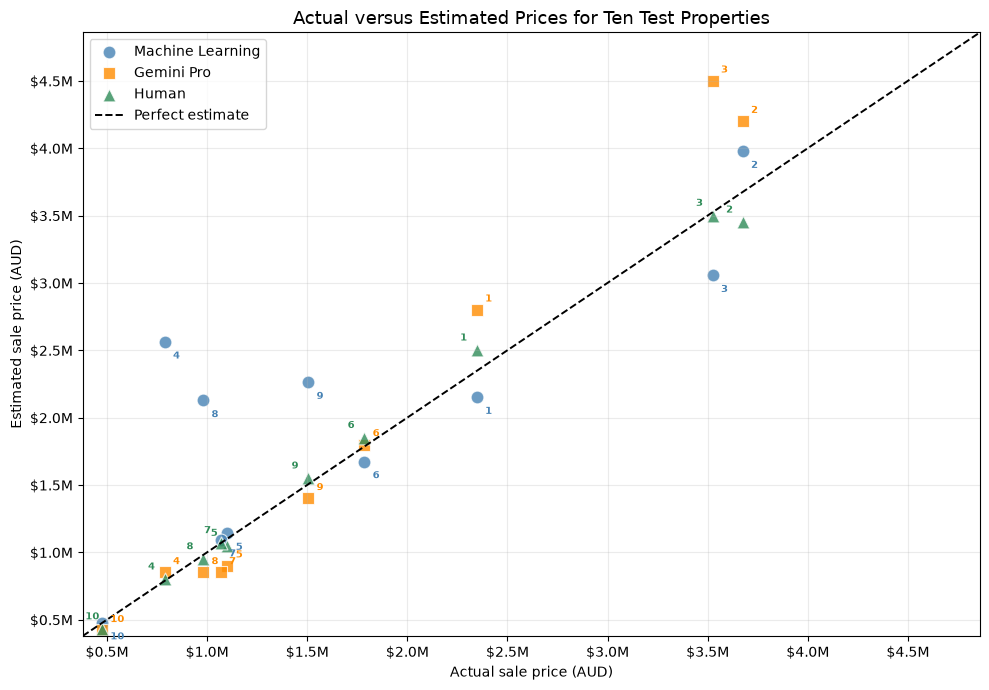

In [87]:
# ============================================================
# ACTUAL VERSUS ESTIMATED PRICES BY APPROACH
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_methods = {
    "Machine Learning": {
        "column": "ML_Prediction",
        "color": "steelblue",
        "marker": "o",
        "offset": (6, -12)                    # Position ML property labels
    },
    "Gemini Pro": {
        "column": "LLM_Estimate",
        "color": "darkorange",
        "marker": "s",
        "offset": (6, 6)                      # Position Gemini property labels
    },
    "Human": {
        "column": "Human_Estimate_AUD",
        "color": "seagreen",
        "marker": "^",
        "offset": (-12, 7)                    # Position human property labels
    }
}

fig, ax = plt.subplots(figsize=(10, 7))

actual = part5_comparison["Actual_Price"]

# Plot and label the estimates from each approach
for method, settings in plot_methods.items():
    predicted = part5_comparison[settings["column"]]

    ax.scatter(
        actual,
        predicted,
        label=method,
        color=settings["color"],
        marker=settings["marker"],
        s=85,
        alpha=0.80,
        edgecolor="white",
        linewidth=0.8
    )

    for property_id, actual_price, estimated_price in zip(
        part5_comparison["Property_ID"],
        actual,
        predicted
    ):
        ax.annotate(
            str(int(property_id)),
            (actual_price, estimated_price),
            xytext=settings["offset"],
            textcoords="offset points",
            fontsize=7,
            color=settings["color"],
            fontweight="bold"
        )

# Calculate common limits for both axes
all_prices = part5_comparison[
    [
        "Actual_Price",
        "ML_Prediction",
        "LLM_Estimate",
        "Human_Estimate_AUD"
    ]
]

minimum_price = all_prices.min().min() * 0.90
maximum_price = all_prices.max().max() * 1.08

# Add the perfect-estimate reference line
ax.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="Perfect estimate"
)

# Format both axes in millions of AUD
millions_formatter = FuncFormatter(
    lambda value, position: f"${value / 1_000_000:.1f}M"
)

ax.xaxis.set_major_formatter(millions_formatter)
ax.yaxis.set_major_formatter(millions_formatter)

ax.set_xlim(minimum_price, maximum_price)
ax.set_ylim(minimum_price, maximum_price)

ax.set_title(
    "Actual versus Estimated Prices for Ten Test Properties",
    fontsize=13
)
ax.set_xlabel("Actual sale price (AUD)")
ax.set_ylabel("Estimated sale price (AUD)")
ax.grid(alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

**Observation.** The human comparable-sales estimates were generally positioned closest to the perfect-estimate line, consistent with their lowest MAE and RMSE. Gemini Pro produced broadly plausible estimates but noticeably overestimated the two highest-priced properties. The machine-learning model accurately estimated several properties, including Properties 5 and 10, but substantially overpredicted some atypically priced properties, producing greater overall error.

These results suggest that comparable-sales judgement can be valuable when suitable reference properties are available, whereas the machine-learning approach provides a more consistent and scalable process. However, the apparent advantage of the human approach must be interpreted cautiously because the estimates were not produced under fully blind conditions and only ten test properties were evaluated.

## 5.4 Comparison of the Three Prediction Approaches

The three approaches were compared using the same ten held-out properties. The human comparable-sales approach achieved the lowest MAE of AUD 65,350 and RMSE of AUD 93,078. Gemini Pro ranked second, with an MAE of AUD 273,950 and RMSE of AUD 394,285. The optimised Random Forest produced the highest errors within this subset, with an MAE of AUD 482,509 and RMSE of AUD 734,905.

The human estimate was closest for seven properties, the machine-learning model for two and Gemini Pro for one. Human judgement performed particularly well when reasonably similar training properties were available, such as the Parramatta townhouse and the Liverpool house. It could manually adjust comparable prices for differences in bedrooms, parking and land size. However, this approach was subjective, time-consuming and difficult to reproduce. Its apparent performance must also be interpreted cautiously because the actual test prices had previously been displayed and the estimates were therefore not produced under fully blind conditions.

The machine-learning model performed well for properties that appeared consistent with patterns represented in the training data. For example, it was the closest approach for Properties 5 and 10. However, it substantially overpredicted unusual properties, particularly Property 4, a lower-priced Mosman apartment, and Property 8, a Liverpool townhouse. These failures demonstrate that Random Forest predictions can be pulled toward the price patterns of superficially similar training properties when important information such as internal floor area, condition, strata costs and renovation quality is unavailable.

Gemini Pro produced plausible estimates and reflected broad relationships between suburb, property type, land size and bedroom count. It was closest for Property 6. Nevertheless, it overestimated several expensive Mosman properties and had no transparent method for assigning weights to the supplied characteristics. LLM estimates may also vary between prompts or model versions, which reduces reproducibility. Unlike the Random Forest, Gemini Pro was not trained directly on the 96 labelled training properties.

Human judgement can still provide value within an automated prediction process. A human reviewer could examine properties flagged as unusual, check whether suitable comparable sales exist and identify contextual information missing from the structured data. Human review may therefore be most useful as an exception-handling or quality-assurance stage rather than as a replacement for automated predictions. It is slower, more subjective and less scalable than machine learning.

Overall, the human approach performed best within this small ten-property comparison, while Gemini Pro provided reasonable but less transparent estimates. Despite ranking third in this subset, the optimised Random Forest remains the most appropriate model for deployment because it was selected using systematic five-fold cross-validation, can process new properties consistently and provides a reproducible prediction pipeline. Its predictions should nevertheless be treated as indicative estimates and referred for human review when a property differs substantially from the training data.

## Part 6: Final Deployment and Reflection

### 6.1 Refit and Save the Final Model

The optimised Random Forest was selected as the deployment model based on its cross-validation performance and reproducible preprocessing pipeline. Before deployment, a fresh copy of the selected pipeline was refitted using all 120 available properties. This allows the deployed model to use all available information.

The reported test-set results remain the final unbiased evaluation because they were calculated before the held-out test properties were included in this final refit. No further performance claims are made using the refitted model.

In [88]:
# ============================================================
# REFIT AND SAVE THE FINAL DEPLOYMENT MODEL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib
import os
import sklearn
import pandas as pd

# Recreate the selected optimised model using the known best parameters
final_model = Pipeline([
    (
        "numeric_imputer",
        PropertyTypeNumericImputer()
    ),                                                          # Impute land and parking
    (
        "preprocessor",
        preprocessor
    ),                                                          # Scale and encode inputs
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,                                   # Best number of trees
            max_depth=None,                                     # Best maximum depth
            min_samples_leaf=1,                                 # Best minimum leaf size
            max_features="sqrt",                                # Best feature sampling
            random_state=42,                                    # Reproducible model
            n_jobs=-1                                           # Use available processors
        )
    )
])

# Refit the complete pipeline using all 120 properties
final_model.fit(X, y)

best_parameters = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_leaf": 1,
    "max_features": "sqrt"
}

# Store the model and deployment information together
deployment_bundle = {
    "model": final_model,
    "predictor_columns": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": "sale_price",
    "training_observations": len(X),
    "model_name": "Optimised Random Forest",
    "best_parameters": best_parameters,
    "sklearn_version": sklearn.__version__,
    "pandas_version": pd.__version__
}

model_filename = "optimised_random_forest_pipeline.joblib"

# Save the deployment bundle
joblib.dump(deployment_bundle, model_filename)

# Reload the saved model and verify that it works
loaded_bundle = joblib.load(model_filename)
loaded_model = loaded_bundle["model"]

verification_prediction = loaded_model.predict(X.iloc[[0]])[0]

print("=== Final Model Saved for Deployment ===")
print(f"Model                 : {deployment_bundle['model_name']}")
print(f"Training observations : {deployment_bundle['training_observations']}")
print(f"Predictor count        : {len(deployment_bundle['predictor_columns'])}")
print(f"Best parameters        : {deployment_bundle['best_parameters']}")
print(f"Saved file             : {model_filename}")
print(f"File size              : {os.path.getsize(model_filename) / 1024:.1f} KB")
print(f"Verification prediction: AUD {verification_prediction:,.0f}")

=== Final Model Saved for Deployment ===
Model                 : Optimised Random Forest
Training observations : 120
Predictor count        : 9
Best parameters        : {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Saved file             : optimised_random_forest_pipeline.joblib
File size              : 1104.0 KB
Verification prediction: AUD 5,426,550


**Observation.** The final optimised Random Forest pipeline was successfully refitted using all 120 properties and saved as a deployment artefact. The saved bundle contains the complete preprocessing and prediction pipeline, the nine required predictor names, the selected hyperparameters and software-version information. Reloading the saved file and generating a verification prediction confirmed that the deployment model remained operational.

## 6.2 Streamlit application

In [97]:
%%writefile app.py

# ============================================================
# SYDNEY PROPERTY PRICE ESTIMATOR
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib

from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Sydney Property Price Estimator",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# CUSTOM IMPUTER REQUIRED BY THE SAVED PIPELINE
# ============================================================

class PropertyTypeNumericImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()

        self.columns_ = [
            "land_size_m2",
            "parking_spaces"
        ]

        self.group_medians_ = {
            column: X.groupby("property_type")[column].median().to_dict()
            for column in self.columns_
        }

        self.overall_medians_ = (
            X[self.columns_].median().to_dict()
        )

        return self

    def transform(self, X):
        X = X.copy()

        for column in self.columns_:

            X[f"{column}_missing"] = (
                X[column].isna().astype(int)
            )

            matched_medians = X["property_type"].map(
                self.group_medians_[column]
            )

            X[column] = (
                X[column]
                .fillna(matched_medians)
                .fillna(self.overall_medians_[column])
            )

        return X


# ============================================================
# CUSTOM APPLICATION STYLING
# ============================================================

st.markdown(
    """
<style>

/* ------------------------------------------------------------
   MAIN PAGE
------------------------------------------------------------ */

.stApp {
    background: #ffffff;
    color: #0b2d63;
}

.block-container {
    max-width: 1450px;
    padding-top: 1.3rem;
    padding-bottom: 2.5rem;
}

div[data-testid="stVerticalBlock"] {
    gap: 0.75rem;
}


/* ------------------------------------------------------------
   HERO BANNER
------------------------------------------------------------ */

.hero-banner {
    position: relative;
    overflow: hidden;
    padding: 25px 32px;
    margin-bottom: 15px;
    border: 1px solid #dbe5ef;
    border-radius: 12px;
    background:
        linear-gradient(
            110deg,
            #ffffff 0%,
            #f6fbff 58%,
            #eaf6fd 100%
        );
}

.hero-banner::after {
    content: "⌂";
    position: absolute;
    right: 38px;
    top: -17px;
    color: rgba(255, 101, 0, 0.08);
    font-size: 145px;
    font-weight: 800;
}

.hero-content {
    position: relative;
    z-index: 2;
}

.hero-title {
    margin: 0;
    color: #082a5e;
    font-size: 2.35rem;
    font-weight: 850;
    line-height: 1.15;
}

.hero-subtitle {
    max-width: 850px;
    margin: 8px 0 15px 0;
    color: #496487;
    font-size: 1rem;
    line-height: 1.5;
}

.hero-badge {
    display: inline-block;
    padding: 6px 13px;
    margin-right: 7px;
    margin-bottom: 3px;
    border: 1px solid #cddcea;
    border-radius: 999px;
    background: #ffffff;
    color: #173c70;
    font-size: 0.84rem;
    font-weight: 650;
}


/* ------------------------------------------------------------
   ABOUT PROJECT
------------------------------------------------------------ */

.about-card {
    display: flex;
    align-items: flex-start;
    gap: 17px;
    padding: 18px 23px;
    margin-bottom: 14px;
    border: 1px solid #dce7f0;
    border-radius: 10px;
    background: #edf7fd;
}

.about-icon {
    flex-shrink: 0;
    color: #ff6500;
    font-size: 2rem;
    line-height: 1;
}

.about-title {
    margin-bottom: 5px;
    color: #082a5e;
    font-size: 1.15rem;
    font-weight: 800;
}

.about-text {
    margin: 0;
    color: #38577e;
    font-size: 0.95rem;
    line-height: 1.55;
}


/* ------------------------------------------------------------
   FORM CARDS
------------------------------------------------------------ */

div[data-testid="stVerticalBlockBorderWrapper"] {
    border: 1px solid #ccd8e5;
    border-radius: 9px;
    background: #ffffff;
    box-shadow: none;
}

.section-heading {
    display: flex;
    align-items: center;
    gap: 11px;
    min-height: 38px;
    margin: 0;
    color: #082a5e;
    font-size: 1.22rem;
    font-weight: 800;
    line-height: 1.2;
}

.section-icon {
    display: inline-flex;
    align-items: center;
    justify-content: center;
    width: 31px;
    height: 31px;
    flex: 0 0 31px;
    color: #ff6500;
    font-size: 1.9rem;
    font-weight: 500;
    line-height: 1;
}

.section-description {
    margin: -2px 0 5px 42px;
    color: #657d9b;
    font-size: 0.88rem;
}


/* ------------------------------------------------------------
   INPUTS
------------------------------------------------------------ */

div[data-testid="stWidgetLabel"] p {
    color: #12376b;
    font-weight: 600;
}

div[data-baseweb="select"] > div,
div[data-testid="stNumberInputContainer"] {
    border-radius: 6px;
    background: #ffffff;
}

div[data-baseweb="select"] > div:focus-within,
div[data-testid="stNumberInputContainer"]:focus-within {
    border-color: #ff6500;
}

input[type="checkbox"] {
    accent-color: #ff6500;
}


/* ------------------------------------------------------------
   ESTIMATE BUTTON
------------------------------------------------------------ */

div[data-testid="stFormSubmitButton"] button {
    min-height: 53px;
    border: 1px solid #ff6500;
    border-radius: 7px;
    background: #ff6500;
    color: #ffffff;
    font-size: 1.04rem;
    font-weight: 750;
    box-shadow: none;
}

div[data-testid="stFormSubmitButton"] button:hover {
    border-color: #e75700;
    background: #e75700;
    color: #ffffff;
}

div[data-testid="stFormSubmitButton"] button:focus {
    border-color: #e75700;
    box-shadow: 0 0 0 0.2rem rgba(255, 101, 0, 0.18);
}


/* ------------------------------------------------------------
   PREDICTION RESULT
------------------------------------------------------------ */

.prediction-card {
    display: flex;
    align-items: center;
    gap: 20px;
    padding: 20px 25px;
    margin: 13px 0;
    border: 1px solid #d5e5ef;
    border-radius: 10px;
    background:
        linear-gradient(
            110deg,
            #edf7fd 0%,
            #f8fcff 100%
        );
}

.prediction-icon {
    display: flex;
    align-items: center;
    justify-content: center;
    width: 78px;
    height: 64px;
    padding-right: 20px;
    flex-shrink: 0;
    border-right: 1px solid #bfcfdf;
}

.prediction-icon svg {
    width: 45px;
    height: 45px;
    stroke: #ff6500;
    stroke-width: 3.5;
}

.prediction-label {
    color: #163a6e;
    font-size: 0.95rem;
    font-weight: 700;
}

.prediction-value {
    margin: 1px 0;
    color: #082a5e;
    font-size: 2.05rem;
    font-weight: 850;
    line-height: 1.12;
}

.prediction-caption {
    color: #617895;
    font-size: 0.85rem;
}


/* ------------------------------------------------------------
   SUBMITTED INFORMATION
------------------------------------------------------------ */

div[data-testid="stExpander"] {
    border: 1px solid #d2dde8;
    border-radius: 8px;
    background: #ffffff;
}

div[data-testid="stDataFrame"] {
    border: 1px solid #dce5ed;
    border-radius: 6px;
}


/* ------------------------------------------------------------
   SIDEBAR
------------------------------------------------------------ */

section[data-testid="stSidebar"] {
    background:
        linear-gradient(
            180deg,
            #eef8fd 0%,
            #f8fcff 100%
        );
    border-right: 1px solid #d7e4ee;
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.5rem;
}

.sidebar-brand {
    display: flex;
    align-items: center;
    gap: 13px;
    padding: 5px 2px 21px 2px;
    margin-bottom: 8px;
    border-bottom: 1px solid #cad9e6;
}

.sidebar-brand-icon {
    display: flex;
    align-items: center;
    justify-content: center;
    width: 47px;
    height: 47px;
    flex: 0 0 47px;
    color: #ff6500;
    font-size: 2.8rem;
    font-weight: 500;
    line-height: 1;
    transform: translateY(-1px);
}

.sidebar-brand-name {
    margin: 0;
    color: #082a5e;
    font-size: 1.08rem;
    font-weight: 850;
    line-height: 1.23;
}

.sidebar-title {
    margin: 17px 0 13px 0;
    color: #082a5e;
    font-size: 1.05rem;
    font-weight: 800;
}

.sidebar-label {
    margin-top: 13px;
    color: #173c70;
    font-size: 0.82rem;
    font-weight: 750;
}

.sidebar-value {
    margin-top: 2px;
    color: #4e6888;
    font-size: 0.89rem;
    line-height: 1.4;
}

.limitation-card {
    padding: 14px;
    margin-top: 22px;
    border-left: 4px solid #ff6500;
    border-radius: 7px;
    background: #fff5ed;
    color: #75401e;
    font-size: 0.84rem;
    line-height: 1.48;
}

.limitation-title {
    margin-bottom: 6px;
    color: #a94300;
    font-weight: 800;
}


/* ------------------------------------------------------------
   STREAMLIT ELEMENTS
------------------------------------------------------------ */

footer {
    visibility: hidden;
}

header[data-testid="stHeader"] {
    background: rgba(255, 255, 255, 0.92);
}


/* ------------------------------------------------------------
   MOBILE DISPLAY
------------------------------------------------------------ */

@media (max-width: 800px) {

    .hero-title {
        font-size: 1.8rem;
    }

    .hero-banner {
        padding: 21px;
    }

    .section-description {
        margin-left: 0;
    }

    .prediction-value {
        font-size: 1.55rem;
    }

    .prediction-icon {
        width: 48px;
        height: 48px;
    }
}

</style>
    """,
    unsafe_allow_html=True
)


# ============================================================
# LOAD THE SAVED MODEL
# ============================================================

MODEL_PATH = (
    Path(__file__).parent
    / "optimised_random_forest_pipeline.joblib"
)


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


try:
    deployment_bundle = load_model()
    model = deployment_bundle["model"]

except FileNotFoundError:
    st.error(
        "The saved model file could not be found. Ensure "
        "'optimised_random_forest_pipeline.joblib' is in the "
        "same folder as app.py."
    )
    st.stop()

except Exception as error:
    st.error(f"The saved model could not be loaded: {error}")
    st.stop()


# ============================================================
# SIDEBAR: MODEL INFORMATION
# ============================================================

with st.sidebar:

    st.markdown(
        """
<div class="sidebar-brand">
<div class="sidebar-brand-icon">⌂</div>
<div class="sidebar-brand-name">Sydney Property<br>Price Estimator</div>
</div>

<div class="sidebar-title">ⓘ &nbsp;Model information</div>

<div class="sidebar-label">MODEL</div>
<div class="sidebar-value">Optimised Random Forest</div>

<div class="sidebar-label">TRAINING OBSERVATIONS</div>
<div class="sidebar-value">120 Sydney property sales recorded between 20 September 2025 and 30 June 2026</div>

<div class="sidebar-label">TYPICAL MODEL ERROR</div>
<div class="sidebar-value">
Held-out test MAE: approximately AUD 404,830.<br>
Five-fold cross-validation MAE: approximately AUD 363,758.<br>
These values represent average absolute errors across evaluation properties, not an error range for an individual property.
</div>

<div class="sidebar-label">PRICE CURRENCY</div>
<div class="sidebar-value">Australian dollars (AUD)</div>

<div class="sidebar-label">NUMBER OF PREDICTORS</div>
<div class="sidebar-value">9</div>

<div class="sidebar-label">SUPPORTED SUBURBS</div>
<div class="sidebar-value">Mosman, Parramatta and Liverpool</div>

<div class="limitation-card">
<div class="limitation-title">ⓘ &nbsp;Important limitation</div>
The training dataset is small and covers only three suburbs.
Unusual properties or properties outside this scope may have
larger prediction errors.
</div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# HERO BANNER
# ============================================================

st.markdown(
    """
<div class="hero-banner">
<div class="hero-content">
<h1 class="hero-title">Sydney Property Price Estimator</h1>
<p class="hero-subtitle">Enter the property and location details below to receive an indicative sale-price estimate from the trained machine-learning model.</p>
<span class="hero-badge">⚙️ &nbsp;Optimised Random Forest</span>
<span class="hero-badge">📊 &nbsp;120 Sydney sales</span>
</div>
</div>
    """,
    unsafe_allow_html=True
)


# ============================================================
# ABOUT THE PROJECT
# ============================================================

st.markdown(
    """
<div class="about-card">
<div class="about-icon">ⓘ</div>
<div>
<div class="about-title">About this project</div>
<p class="about-text">This application was created as part of a student machine-learning project to explore how property characteristics and location influence residential sale prices across Mosman, Parramatta and Liverpool.</p>
</div>
</div>
    """,
    unsafe_allow_html=True
)


# ============================================================
# PROPERTY INPUT FORM
# ============================================================

with st.form("property_form"):

    location_column, property_column = st.columns(
        [0.82, 1.18],
        gap="medium"
    )

    # --------------------------------------------------------
    # LOCATION INPUTS
    # --------------------------------------------------------

    with location_column:

        with st.container(border=True):

            st.markdown(
                """
<div class="section-heading">
<span class="section-icon">⌖</span>
<span>Location</span>
</div>
                """,
                unsafe_allow_html=True
            )

            st.markdown(
                """
<div class="section-description">
Enter the location characteristics of the property.
</div>
                """,
                unsafe_allow_html=True
            )

            suburb = st.selectbox(
                "Suburb",
                [
                    "Mosman",
                    "Parramatta",
                    "Liverpool"
                ]
            )

            distance_to_cbd_km = st.number_input(
                "Distance to Sydney CBD (km)",
                min_value=0.0,
                max_value=50.0,
                value=5.0,
                step=0.1,
                format="%.2f"
            )

            distance_to_station_km = st.number_input(
                "Distance to nearest station (km)",
                min_value=0.0,
                max_value=10.0,
                value=2.1,
                step=0.1,
                format="%.2f"
            )

    # --------------------------------------------------------
    # PROPERTY INPUTS
    # --------------------------------------------------------

    with property_column:

        with st.container(border=True):

            st.markdown(
                """
<div class="section-heading">
<span class="section-icon">⌂</span>
<span>Property details</span>
</div>
                """,
                unsafe_allow_html=True
            )

            st.markdown(
                """
<div class="section-description">
Enter the main characteristics of the property.
</div>
                """,
                unsafe_allow_html=True
            )

            first_column, second_column = st.columns(2)

            with first_column:

                property_type = st.selectbox(
                    "Property type",
                    [
                        "House",
                        "Apartment-Unit",
                        "Townhouse"
                    ]
                )

                bathrooms = st.number_input(
                    "Bathrooms",
                    min_value=1,
                    max_value=10,
                    value=2,
                    step=1
                )

            with second_column:

                bedrooms = st.number_input(
                    "Bedrooms",
                    min_value=1,
                    max_value=10,
                    value=3,
                    step=1
                )

                parking_spaces_input = st.number_input(
                    "Parking spaces",
                    min_value=0,
                    max_value=10,
                    value=1,
                    step=1
                )

            parking_unknown = st.checkbox(
                "Parking information unavailable"
            )

            land_column, land_checkbox_column = st.columns(
                [1, 1]
            )

            with land_column:

                land_size_input = st.number_input(
                    "Land size (m²)",
                    min_value=1.0,
                    max_value=3000.0,
                    value=370.0,
                    step=10.0,
                    format="%.2f"
                )

            with land_checkbox_column:

                st.markdown(
                    "<br>",
                    unsafe_allow_html=True
                )

                land_unknown = st.checkbox(
                    "Land-size information unavailable"
                )

            sale_method = st.selectbox(
                "Sale method",
                [
                    "Auction",
                    "Private Treaty",
                    "Sold prior to auction"
                ]
            )

    predict_button = st.form_submit_button(
        "Estimate sale price",
        use_container_width=True
    )


# ============================================================
# GENERATE AND DISPLAY PREDICTION
# ============================================================

if predict_button:

    parking_spaces = (
        np.nan
        if parking_unknown
        else parking_spaces_input
    )

    land_size_m2 = (
        np.nan
        if land_unknown
        else land_size_input
    )

    property_input = pd.DataFrame({
        "bedrooms": [bedrooms],
        "bathrooms": [bathrooms],
        "parking_spaces": [parking_spaces],
        "land_size_m2": [land_size_m2],
        "distance_to_cbd_km": [distance_to_cbd_km],
        "distance_to_station_km": [distance_to_station_km],
        "suburb": [suburb],
        "property_type": [property_type],
        "sale_method": [sale_method]
    })

    # Match the exact predictor order used during training
    property_input = property_input[
        deployment_bundle["predictor_columns"]
    ]

    try:
        estimated_price = model.predict(
            property_input
        )[0]

        st.markdown(
            f"""
        <div class="prediction-card">
        <div class="prediction-icon">
        <svg viewBox="0 0 48 48" fill="none" xmlns="http://www.w3.org/2000/svg">
        <path d="M7 36L17 25L24 31L34 16L41 22" stroke-linecap="round" stroke-linejoin="round"/>
        <circle cx="7" cy="36" r="2.5" fill="#ff6500" stroke="none"/>
        <circle cx="17" cy="25" r="2.5" fill="#ff6500" stroke="none"/>
        <circle cx="24" cy="31" r="2.5" fill="#ff6500" stroke="none"/>
        <circle cx="34" cy="16" r="2.5" fill="#ff6500" stroke="none"/>
        <circle cx="41" cy="22" r="2.5" fill="#ff6500" stroke="none"/>
        </svg>
        </div>
        <div>
        <div class="prediction-label">Estimated sale price</div>
        <div class="prediction-value">AUD {estimated_price:,.0f}</div>
        <div class="prediction-caption">Indicative estimate only — not a current professional property valuation.</div>
        </div>
        </div>
            """,
            unsafe_allow_html=True
        )

        with st.expander(
            "▦  View submitted property information",
            expanded=True
        ):

            display_input = property_input.copy()

            display_input["parking_spaces"] = (
                display_input["parking_spaces"]
                .apply(
                    lambda value:
                    "Unavailable"
                    if pd.isna(value)
                    else int(value)
                )
            )

            display_input["land_size_m2"] = (
                display_input["land_size_m2"]
                .apply(
                    lambda value:
                    "Unavailable"
                    if pd.isna(value)
                    else f"{value:,.0f}"
                )
            )

            display_input.columns = [
                column.replace("_", " ").title()
                for column in display_input.columns
            ]

            st.dataframe(
                display_input,
                hide_index=True,
                use_container_width=True
            )

    except Exception as error:
        st.error(
            f"The estimate could not be generated: {error}"
        )


# ============================================================
# FOOTNOTE
# ============================================================

st.caption(
    "Machine-learning project • Predictions are limited "
    "by the size, location coverage and available features of "
    "the training dataset."
)

Overwriting app.py


In [98]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


### 6.2 Streamlit Web Application

A web-based property price estimation application was developed using Streamlit. The application loads the saved optimised Random Forest pipeline and allows users to enter the same nine property predictors used during model development: suburb, property type, bedrooms, bathrooms, parking spaces, land size, sale method, distance to the CBD and distance to the nearest station.

When the user selects **Estimate sale price**, the entered values are converted into a one-row pandas DataFrame with the required model structure. The saved pipeline then applies missing-value imputation, numerical standardisation and categorical one-hot encoding before generating the estimated sale price.

The application also allows users to indicate that parking or land-size information is unavailable. These values are passed to the pipeline as missing values and processed by the property-type-specific imputer developed during model training. A warning informs users that the model was trained using only 120 properties from Mosman, Parramatta and Liverpool and that its output is an indicative estimate rather than a professional valuation.

In [91]:
# ============================================================
# DISPLAY DEPLOYMENT PACKAGE VERSIONS
# ============================================================

import streamlit
import pandas
import numpy
import sklearn
import joblib

print("=== Deployment Package Versions ===")
print(f"streamlit       == {streamlit.__version__}")
print(f"pandas          == {pandas.__version__}")
print(f"numpy           == {numpy.__version__}")
print(f"scikit-learn    == {sklearn.__version__}")
print(f"joblib          == {joblib.__version__}")

=== Deployment Package Versions ===
streamlit       == 1.63.0
pandas          == 3.0.3
numpy           == 2.5.0
scikit-learn    == 1.9.0
joblib          == 1.5.3


In [99]:
%%writefile requirements.txt
streamlit==1.63.0
pandas==3.0.3
numpy==2.5.0
scikit-learn==1.9.0
joblib==1.5.3

Overwriting requirements.txt


In [93]:
# ============================================================
# TEST THE JUPYTER FINAL MODEL WITH THE APP INPUTS
# ============================================================

import pandas as pd

app_property = pd.DataFrame({
    "bedrooms": [3],
    "bathrooms": [2],
    "parking_spaces": [1],
    "land_size_m2": [370.0],
    "distance_to_cbd_km": [5.0],
    "distance_to_station_km": [2.1],
    "suburb": ["Mosman"],
    "property_type": ["House"],
    "sale_method": ["Auction"]
})

# Match the predictor order used to fit the model
app_property = app_property[X.columns]

# Predict directly using the refitted Jupyter model
notebook_prediction = final_model.predict(app_property)[0]

print("=== Jupyter Final Model Prediction ===")
print(app_property.to_string(index=False))
print(f"\nPredicted sale price: AUD {notebook_prediction:,.0f}")

=== Jupyter Final Model Prediction ===
 bedrooms  bathrooms  parking_spaces  land_size_m2  distance_to_cbd_km  distance_to_station_km suburb property_type sale_method
        3          2               1         370.0                 5.0                     2.1 Mosman         House     Auction

Predicted sale price: AUD 3,042,945


**Deployment verification.** The same property inputs were submitted to the refitted model directly in Jupyter and through the Streamlit application. Both produced an estimated sale price of **AUD 3,042,945**, confirming that the application correctly passes the nine predictor values through the saved preprocessing and Random Forest pipeline.